<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/text-analytics-spring-2026/blob/main/Assignment%203/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
!pip install gensim
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
from wordcloud import WordCloud
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# Load dataset
import kagglehub
path = kagglehub.dataset_download("arushchillar/disneyland-reviews")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'disneyland-reviews' dataset.
Dataset downloaded to: /kaggle/input/disneyland-reviews


In [ ]:
df = pd.read_csv(path + "/DisneylandReviews.csv", encoding="latin-1")
df.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42656 entries, 0 to 42655
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Review_ID          42656 non-null  int64 
 1   Rating             42656 non-null  int64 
 2   Year_Month         42656 non-null  object
 3   Reviewer_Location  42656 non-null  object
 4   Review_Text        42656 non-null  object
 5   Branch             42656 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.0+ MB


In [ ]:
# Confirming that there are only three values for the branches
df['Branch'].unique()

array(['Disneyland_HongKong', 'Disneyland_California', 'Disneyland_Paris'],
      dtype=object)

In [ ]:
california = df[df['Branch']=="Disneyland_California"]
paris = df[df['Branch']=="Disneyland_Paris"]
hongkong = df[df['Branch']=="Disneyland_HongKong"]

In [ ]:
pd.set_option('display.max_colwidth', None)


## EDA

California Disneyland: 19406 reviews
Paris Disneyland: 13630 reviews 
Hong Kong Disneyland: 9620 reviews 


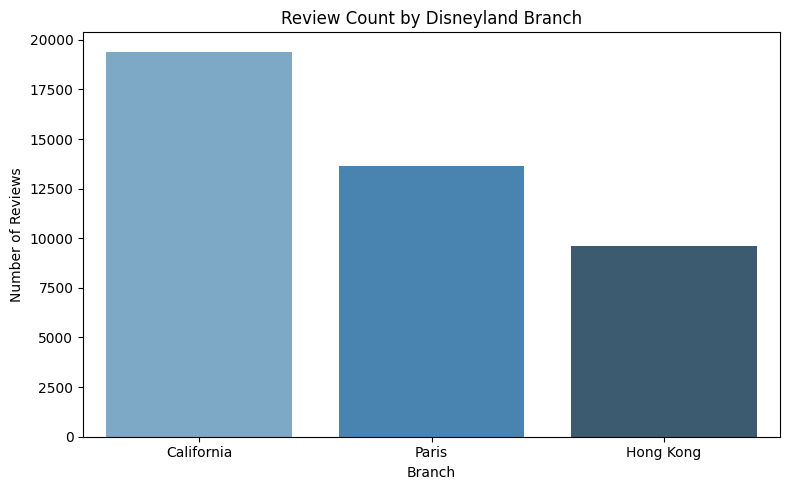

In [ ]:
# Review count
import seaborn as sns
print(f"California Disneyland: {len(california)} reviews")
print(f"Paris Disneyland: {len(paris)} reviews ")
print(f"Hong Kong Disneyland: {len(hongkong)} reviews ")

group_counts = pd.DataFrame({
    'Branch': ['California', 'Paris', 'Hong Kong'],
    'Reviews': [len(california), len(paris), len(hongkong)]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=group_counts, x='Branch', y='Reviews', hue='Branch', palette='Blues_d', legend=False)
plt.title('Review Count by Disneyland Branch')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

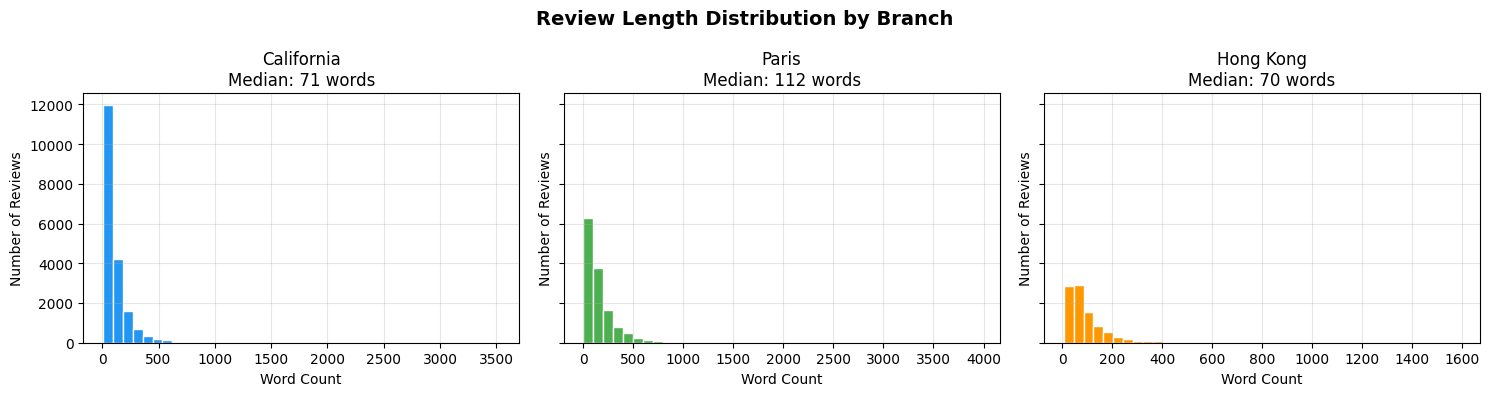

In [ ]:
# Review length distribution
california['word_count'] = california['Review_Text'].str.split().str.len()
paris['word_count'] = paris['Review_Text'].str.split().str.len()
hongkong['word_count'] = hongkong['Review_Text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, df, name, color in zip(
    axes,
    [california, paris, hongkong],
    ['California', 'Paris', 'Hong Kong'],
    ['#2196F3', '#4CAF50', '#FF9800']
):
    ax.hist(df['word_count'], bins=40, color=color, edgecolor='white')
    ax.set_title(f'{name}\nMedian: {df["word_count"].median():.0f} words')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Number of Reviews')
    ax.grid(True, alpha=0.3)

plt.suptitle('Review Length Distribution by Branch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def basic_text_stats(df):
    words = " ".join(df['Review_Text'].astype(str)).lower().split()

    total_words = len(words)
    unique_words = len(set(words))
    avg_length = df['Review_Text'].str.split().str.len().mean()

    return total_words, unique_words, avg_length

# Calculate basic text statistics for each branch
ca_total, ca_vocab, ca_avg = basic_text_stats(california)
pa_total, pa_vocab, pa_avg = basic_text_stats(paris)
hk_total, hk_vocab, hk_avg = basic_text_stats(hongkong)

# Print results
print(f"California \u2192 Total Words: {ca_total:,} | Unique Words: {ca_vocab:,} | Avg Review Length: {ca_avg:.1f}")
print(f"Paris      \u2192 Total Words: {pa_total:,} | Unique Words: {pa_vocab:,} | Avg Review Length: {pa_avg:.1f}")
print(f"Hong Kong  \u2192 Total Words: {hk_total:,} | Unique Words: {hk_vocab:,} | Avg Review Length: {hk_avg:.1f}")

California → Total Words: 2,240,404 | Unique Words: 64,394 | Avg Review Length: 115.4
Paris      → Total Words: 2,308,510 | Unique Words: 75,531 | Avg Review Length: 169.4
Hong Kong  → Total Words: 983,732 | Unique Words: 40,860 | Avg Review Length: 102.3


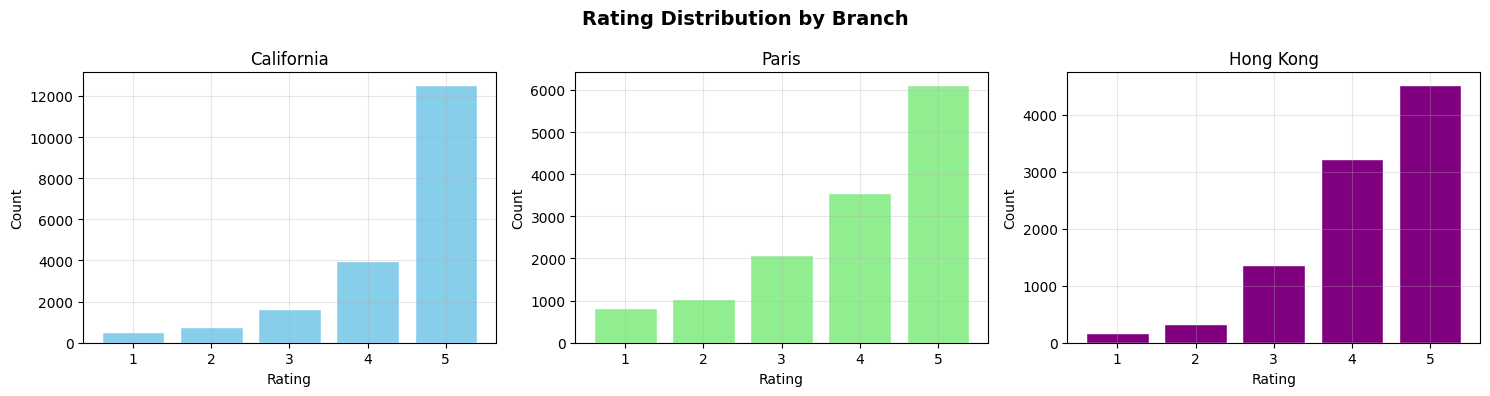

In [ ]:
# Rating Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, df, name, color in zip(axes,
                                [california, paris, hongkong],
                                ['California', 'Paris', 'Hong Kong'],
                                ['skyblue', 'lightgreen', 'purple']):
    counts = df['Rating'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_title(f'{name}')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.suptitle('Rating Distribution by Branch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from nltk.corpus import stopwords
import nltk
import re

nltk.download("stopwords")

custom_stopwords = set(stopwords.words("english"))

custom_stopwords.update([
    "disneyland",
    "disney",
    "park",
    "parks",
    "day",
    "time",
    "went",
    "also",
    "really",
    "just"
])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# We added additional stopwords to make sure we are actually getting the most impactful content for the analysis. We ran the function below with top words and continued to add to our custom stopwords list.

custom_stopwords.update([
    "ride",
    "hong",
    "kong",
    "paris",
    'get',
    "mickey",
    "rides",
    "queue",
    "line",
    "lines",
    "wait",
    "waiting",
    "place",
    "visit",
    "visited"
])

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk
import re

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'\S+@\S+|http\S+|\d+', ' ', str(text))
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()

    words = text.split()

    tokens = [
        lemmatizer.lemmatize(word, pos="v")
        for word in words
        if word not in custom_stopwords
        and word.isalpha()
        and len(word) > 2
    ]

    return tokens

california["tokens"] = california["Review_Text"].apply(clean_text)
paris["tokens"] = paris["Review_Text"].apply(clean_text)
hongkong["tokens"] = hongkong["Review_Text"].apply(clean_text)

california["clean"] = california["tokens"].apply(lambda x: " ".join(x))
paris["clean"] = paris["tokens"].apply(lambda x: " ".join(x))
hongkong["clean"] = hongkong["tokens"].apply(lambda x: " ".join(x))

california = california[california["tokens"].apply(len) >= 5].copy()
paris = paris[paris["tokens"].apply(len) >= 5].copy()
hongkong = hongkong[hongkong["tokens"].apply(len) >= 5].copy()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
for i in range(3):
    print("\nExample", i+1)
    print("Original:", california["Review_Text"].iloc[i][:300])
    print("Cleaned:", california["clean"].iloc[i][:300])


Example 1
Original: This place has always been and forever will be special. The feeling you get entering the park, seeing the characters and different attractions is just priceless. This is definitely a dream trip for all ages, especially young kids. Spend the money and go to Disneyland, you will NOT regret it
Cleaned: always forever special feel enter see character different attractions priceless definitely dream trip age especially young kid spend money regret

Example 2
Original: A great day of simple fun and thrills. Bring cash, nothing is cheap, but we knew that it's Disney. But they are great letting you bring in your own food, drinks, etc but read the list closely, we list several items at the entry gates (selfy sticks, glass refill bottles, etc). It is worth buying the 
Cleaned: great simple fun thrill bring cash nothing cheap know great let bring food drink etc read list closely list several items entry gate selfy stick glass refill bottle etc worth buy photo pass fastpass fu

In [ ]:
from gensim.corpora import Dictionary

def build_gensim_inputs(df, name):
    dictionary = Dictionary(df["tokens"])
    dictionary.filter_extremes(no_below=5, no_above=0.80)

    corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

    print(f"{name}")
    print(f"Documents: {len(corpus)}")
    print(f"Vocabulary size: {len(dictionary)}")
    print()

    return dictionary, corpus

california_dict, california_corpus = build_gensim_inputs(california, "California")
paris_dict, paris_corpus = build_gensim_inputs(paris, "Paris")
hongkong_dict, hongkong_corpus = build_gensim_inputs(hongkong, "Hong Kong")

California
Documents: 19341
Vocabulary size: 5898

Paris
Documents: 13616
Vocabulary size: 6119

Hong Kong
Documents: 9606
Vocabulary size: 3881



In [ ]:
from collections import Counter
def print_top_words(df, name, text_col="clean"):
    words = " ".join(df[text_col].astype(str)).lower().split()
    top10 = Counter(words).most_common(10)

    print(f"\nTop 10 words in {name}:")
    for word, count in top10:
        print(f"{word}: {count}")

print_top_words(california, "California")
print_top_words(paris, "Paris")
print_top_words(hongkong, "Hong Kong")


Top 10 words in California:
pass: 8630
one: 7703
great: 7650
love: 6509
kid: 6484
crowd: 6263
see: 6191
take: 6134
make: 5925
like: 5676

Top 10 words in Paris:
one: 8052
queue: 6969
food: 6901
would: 6872
take: 6409
see: 6206
good: 6175
great: 5868
show: 5717
kid: 5524

Top 10 words in Hong Kong:
kid: 4317
one: 3792
show: 3783
food: 3228
take: 3132
parade: 3122
great: 3109
good: 2960
enjoy: 2740
like: 2587


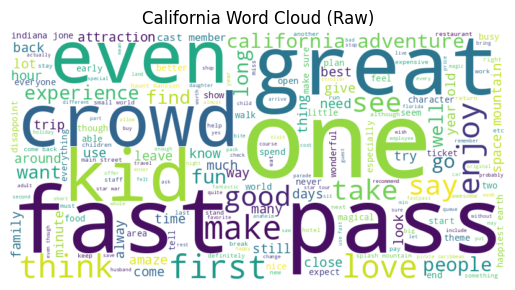

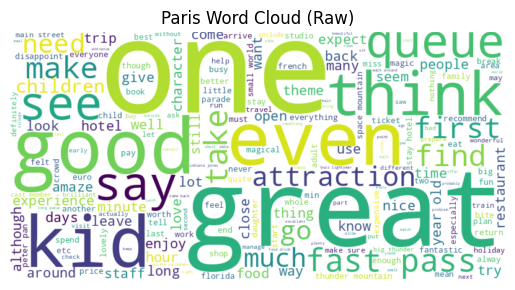

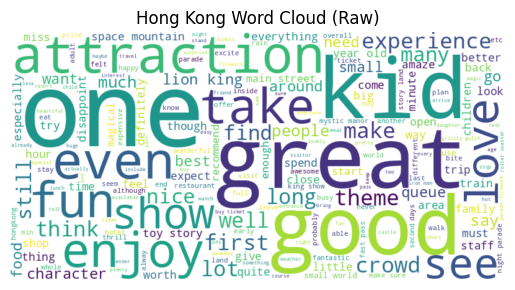

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def wordcloud_plot(df, title):
    text = " ".join(df['clean'].astype(str))

    wc = WordCloud(width=800, height=400,
                   background_color='white').generate(text)

    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

wordcloud_plot(california, "California Word Cloud (Raw)")
wordcloud_plot(paris, "Paris Word Cloud (Raw)")
wordcloud_plot(hongkong, "Hong Kong Word Cloud (Raw)")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def create_dtm(df, name):
    vectorizer = CountVectorizer(
        max_df=0.90,
        min_df=5
    )

    dtm = vectorizer.fit_transform(df["clean"])

    print(f"{name} DTM shape: {dtm.shape}")

    return dtm, vectorizer

california_dtm, california_vec = create_dtm(california, "California")
paris_dtm, paris_vec = create_dtm(paris, "Paris")
hongkong_dtm, hongkong_vec = create_dtm(hongkong, "Hong Kong")

California DTM shape: (19341, 5898)
Paris DTM shape: (13616, 6119)
Hong Kong DTM shape: (9606, 3881)


## Model 1: LDA (Latent Dirichlet Allocation(LDA)

LDA is a topic modeling algorithm that uses probabilities to discover hidden themes across a collection of documents. We used LDA to identify the major themes in visitor reviews from the California, Paris, and Hong Kong Disneyland datasets.

In [ ]:
from gensim.models import LdaModel

def run_gensim_lda(corpus, dictionary, k, name):
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha="auto",
        eta="auto"
    )

    print(f"\nTop words for {name} with k={k}")
    for topic_num, topic_words in lda_model.print_topics(num_topics=k, num_words=20):
        print(f"Topic {topic_num+1}: {topic_words}")

    return lda_model

In [ ]:
k_values = [5, 8, 10, 12, 15]

california_lda_models = {}
paris_lda_models = {}
hongkong_lda_models = {}

for k in k_values:
    california_lda_models[k] = run_gensim_lda(california_corpus, california_dict, k, "California")


Top words for California with k=5
Topic 1: 0.032*"mountain" + 0.018*"space" + 0.014*"pirate" + 0.014*"jones" + 0.013*"indiana" + 0.011*"show" + 0.011*"star" + 0.010*"splash" + 0.010*"tour" + 0.009*"california" + 0.009*"haunt" + 0.009*"adventure" + 0.008*"thunder" + 0.007*"eat" + 0.007*"mansion" + 0.007*"caribbean" + 0.007*"matterhorn" + 0.007*"like" + 0.007*"big" + 0.007*"small"
Topic 2: 0.037*"world" + 0.018*"florida" + 0.015*"california" + 0.014*"much" + 0.014*"better" + 0.014*"disneyworld" + 0.013*"magic" + 0.013*"attractions" + 0.012*"like" + 0.012*"crowd" + 0.012*"christmas" + 0.011*"smaller" + 0.011*"many" + 0.010*"close" + 0.010*"orlando" + 0.010*"small" + 0.010*"time" + 0.010*"compare" + 0.010*"original" + 0.009*"kingdom"
Topic 3: 0.021*"great" + 0.019*"love" + 0.017*"kid" + 0.015*"fun" + 0.013*"see" + 0.011*"year" + 0.010*"enjoy" + 0.010*"always" + 0.009*"family" + 0.009*"old" + 0.009*"make" + 0.009*"like" + 0.009*"experience" + 0.008*"much" + 0.008*"every" + 0.008*"take" + 0

In [ ]:
for k in k_values:
    paris_lda_models[k] = run_gensim_lda(paris_corpus, paris_dict, k, "Paris")


Top words for Paris with k=5
Topic 1: 0.015*"character" + 0.014*"see" + 0.013*"parade" + 0.012*"show" + 0.012*"kid" + 0.012*"great" + 0.010*"queue" + 0.010*"love" + 0.010*"children" + 0.009*"would" + 0.009*"year" + 0.008*"take" + 0.008*"old" + 0.008*"good" + 0.007*"make" + 0.007*"lot" + 0.007*"meet" + 0.007*"amaze" + 0.007*"one" + 0.007*"days"
Topic 2: 0.016*"food" + 0.014*"good" + 0.012*"great" + 0.012*"florida" + 0.011*"attractions" + 0.011*"close" + 0.010*"like" + 0.010*"much" + 0.009*"many" + 0.008*"experience" + 0.008*"better" + 0.008*"still" + 0.008*"world" + 0.008*"lot" + 0.007*"fun" + 0.007*"well" + 0.007*"theme" + 0.007*"would" + 0.007*"time" + 0.007*"one"
Topic 3: 0.017*"food" + 0.017*"hotel" + 0.015*"ticket" + 0.014*"take" + 0.010*"pass" + 0.010*"fast" + 0.010*"one" + 0.010*"stay" + 0.009*"euros" + 0.009*"drink" + 0.008*"buy" + 0.008*"queue" + 0.008*"eat" + 0.008*"book" + 0.008*"price" + 0.007*"expensive" + 0.007*"good" + 0.007*"get" + 0.006*"use" + 0.006*"train"
Topic 4: 0

In [ ]:
for k in k_values:
    hongkong_lda_models[k] = run_gensim_lda(hongkong_corpus, hongkong_dict, k, "Hong Kong")


Top words for Hong Kong with k=5
Topic 1: 0.015*"kid" + 0.013*"one" + 0.013*"small" + 0.013*"great" + 0.011*"would" + 0.011*"good" + 0.011*"food" + 0.011*"much" + 0.009*"fun" + 0.008*"children" + 0.008*"like" + 0.008*"still" + 0.007*"well" + 0.007*"staff" + 0.007*"experience" + 0.007*"smaller" + 0.007*"think" + 0.007*"love" + 0.006*"even" + 0.006*"people"
Topic 2: 0.024*"mountain" + 0.020*"space" + 0.015*"land" + 0.014*"show" + 0.013*"toy" + 0.012*"story" + 0.012*"grizzly" + 0.011*"mystic" + 0.010*"like" + 0.009*"small" + 0.008*"world" + 0.008*"gulch" + 0.008*"manor" + 0.007*"king" + 0.007*"lion" + 0.007*"main" + 0.007*"jungle" + 0.007*"cruise" + 0.006*"street" + 0.006*"pooh"
Topic 3: 0.020*"enjoy" + 0.015*"weather" + 0.014*"show" + 0.013*"hot" + 0.012*"come" + 0.011*"kid" + 0.011*"crowd" + 0.010*"parade" + 0.010*"one" + 0.009*"like" + 0.009*"long" + 0.009*"family" + 0.009*"bring" + 0.008*"good" + 0.008*"holiday" + 0.008*"experience" + 0.008*"attraction" + 0.007*"every" + 0.007*"back"

In [ ]:
from gensim.models import CoherenceModel

def compute_coherence_values(corpus, dictionary, texts, k_values, name):
    coherence_scores = []

    print(f"\n{name} coherence scores")

    for k in k_values:
        lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=42,
            passes=10,
            alpha="auto",
            eta="auto"
        )

        coherence_model = CoherenceModel(
            model=lda_model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )

        score = coherence_model.get_coherence()
        coherence_scores.append(score)

        print(f"k={k}: coherence={score:.4f}")

    return coherence_scores

In [ ]:
california_coherence = compute_coherence_values(
    california_corpus, california_dict, california["tokens"], k_values, "California"
)

paris_coherence = compute_coherence_values(
    paris_corpus, paris_dict, paris["tokens"], k_values, "Paris"
)

hongkong_coherence = compute_coherence_values(
    hongkong_corpus, hongkong_dict, hongkong["tokens"], k_values, "Hong Kong"
)


California coherence scores
k=5: coherence=0.4634
k=8: coherence=0.4660
k=10: coherence=0.4930
k=12: coherence=0.4910
k=15: coherence=0.4711

Paris coherence scores
k=5: coherence=0.3913
k=8: coherence=0.4275
k=10: coherence=0.4053
k=12: coherence=0.4200
k=15: coherence=0.4307

Hong Kong coherence scores
k=5: coherence=0.4262
k=8: coherence=0.4654
k=10: coherence=0.4757
k=12: coherence=0.4447
k=15: coherence=0.4706


### Final LDA Topic Selection

Based on coherence scores, the final number of topics selected for each branch was:

- California: k = 10
- Paris: k = 8
- Hong Kong: k = 10

In [ ]:
best_k = {
    "California": 10,
    "Paris": 8,
    "Hong Kong": 10
}

final_lda_models = {
    "California": california_lda_models[10],
    "Paris": paris_lda_models[8],
    "Hong Kong": hongkong_lda_models[10]
}

In [ ]:
print("California perplexity:", final_lda_models["California"].log_perplexity(california_corpus))
print("Paris perplexity:", final_lda_models["Paris"].log_perplexity(paris_corpus))
print("Hong Kong perplexity:", final_lda_models["Hong Kong"].log_perplexity(hongkong_corpus))

California perplexity: -7.023253829882776
Paris perplexity: -7.056501847118855
Hong Kong perplexity: -6.9512597890054275


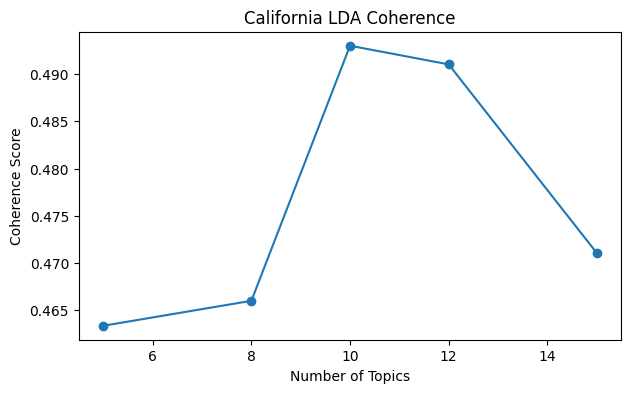

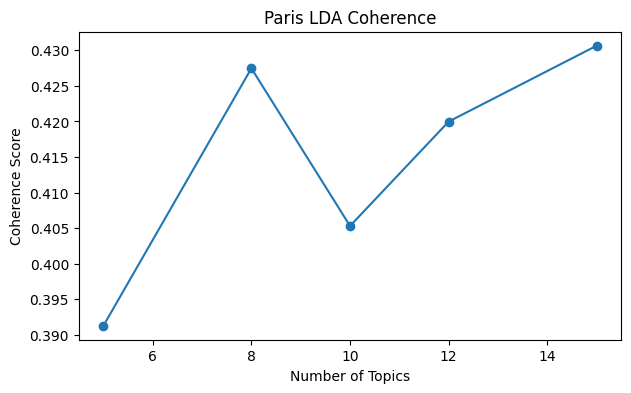

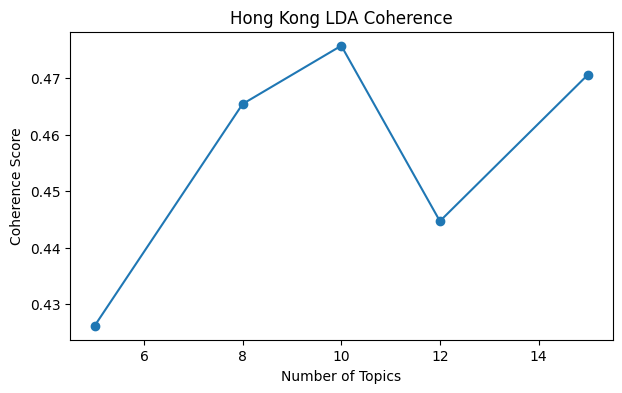

In [ ]:
import matplotlib.pyplot as plt

def plot_coherence(k_values, scores, name):
    plt.figure(figsize=(7, 4))
    plt.plot(k_values, scores, marker="o")
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Score")
    plt.title(f"{name} LDA Coherence")
    plt.show()

plot_coherence(k_values, california_coherence, "California")
plot_coherence(k_values, paris_coherence, "Paris")
plot_coherence(k_values, hongkong_coherence, "Hong Kong")

Final topic numbers were selected based on coherence scores:

California: k = 10
Paris: k = 8
Hong Kong: k = 10

In [ ]:
def get_gensim_topic_df(model, corpus):
    rows = []

    for doc in corpus:
        topic_dist = dict(model.get_document_topics(doc, minimum_probability=0))
        rows.append([topic_dist[i] for i in range(model.num_topics)])

    topic_df = pd.DataFrame(
        rows,
        columns=[f"Topic_{i}" for i in range(model.num_topics)]
    )

    return topic_df

In [ ]:
california_topic_probs = get_gensim_topic_df(final_lda_models["California"], california_corpus)
paris_topic_probs = get_gensim_topic_df(final_lda_models["Paris"], paris_corpus)
hongkong_topic_probs = get_gensim_topic_df(final_lda_models["Hong Kong"], hongkong_corpus)

california = california.reset_index(drop=True)
paris = paris.reset_index(drop=True)
hongkong = hongkong.reset_index(drop=True)

california["dominant_topic"] = california_topic_probs.idxmax(axis=1)
paris["dominant_topic"] = paris_topic_probs.idxmax(axis=1)
hongkong["dominant_topic"] = hongkong_topic_probs.idxmax(axis=1)

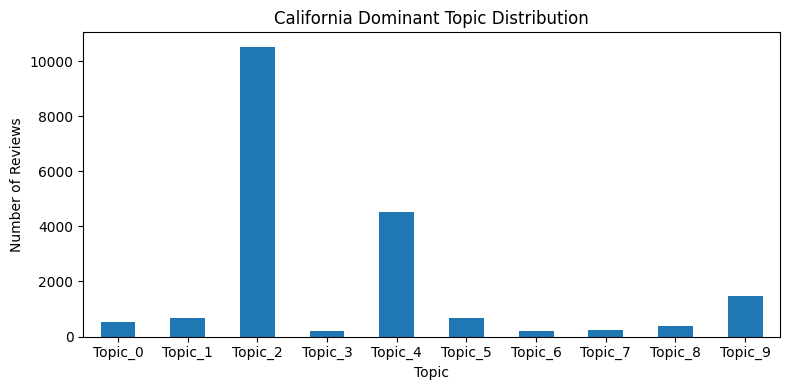

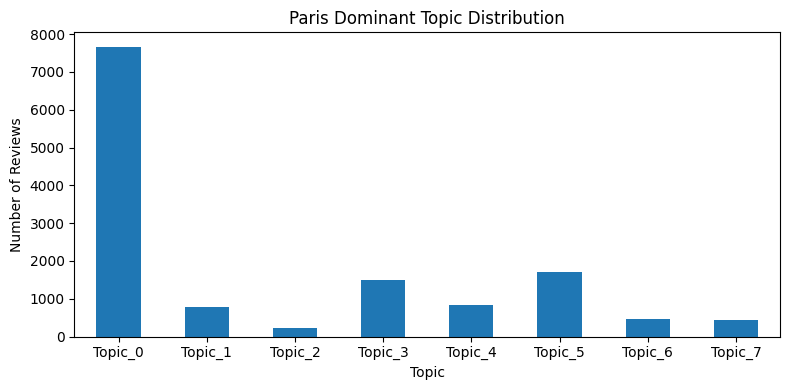

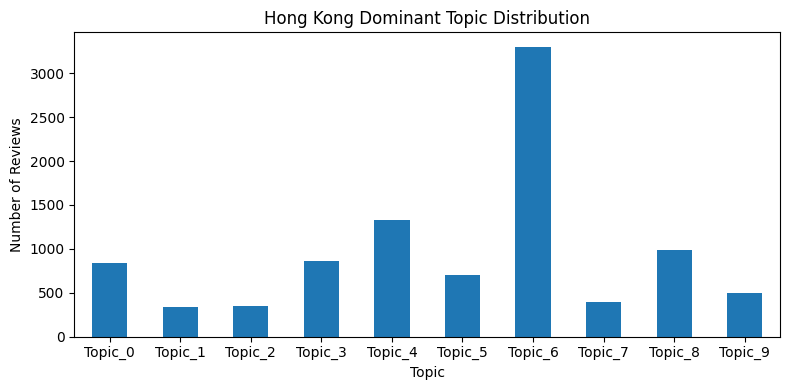

In [ ]:
def plot_topic_prevalence(df, name):
    topic_counts = df["dominant_topic"].value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    topic_counts.plot(kind="bar")

    plt.title(f"{name} Dominant Topic Distribution")
    plt.xlabel("Topic")
    plt.ylabel("Number of Reviews")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_topic_prevalence(california, "California")
plot_topic_prevalence(paris, "Paris")
plot_topic_prevalence(hongkong, "Hong Kong")

In [ ]:
comparison_df = pd.DataFrame({
    "California": california["dominant_topic"].value_counts(normalize=True).sort_index(),
    "Paris": paris["dominant_topic"].value_counts(normalize=True).sort_index(),
    "Hong Kong": hongkong["dominant_topic"].value_counts(normalize=True).sort_index()
}).fillna(0)

comparison_df

,California,Paris,Hong Kong
dominant_topic,,,
Topic_0,0.027610,0.562867,0.087654
Topic_1,0.034331,0.057653,0.035290
Topic_2,0.543871,0.017259,0.036540
Topic_3,0.010392,0.110018,0.089944
Topic_4,0.233545,0.061105,0.138559
Topic_5,0.034073,0.125441,0.072767
Topic_6,0.009669,0.034151,0.343639
Topic_7,0.012099,0.031507,0.040496
Topic_8,0.019130,0.000000,0.103269


In [ ]:
!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

vis_ca = gensimvis.prepare(
    final_lda_models["California"],
    california_corpus,
    california_dict
)

pyLDAvis.display(vis_ca)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
vis_paris = gensimvis.prepare(
    final_lda_models["Paris"],
    paris_corpus,
    paris_dict
)

pyLDAvis.display(vis_paris)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
vis_hongkong = gensimvis.prepare(
    final_lda_models["Hong Kong"],
    hongkong_corpus,
    hongkong_dict
)

pyLDAvis.display(vis_hongkong)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The intertopic distance map for all three Disneyland parks show that most topics are reasonably well separated, indicating that the selected number of topics produces distinct thematic clusters. There is a small overlap between a small number of topics but the majority remain clearly differentiated. The clear distinctions suggest the model captures meaningful variation in visitor experiences across reviews.

The limited overlap between topics further supports the coherence based selection of k used earlier. The chosen number of topics balance interpretability and thematic separation.

In [ ]:
def show_top_documents(df, topic_df, topic_num, top_n=5):
    temp = df.copy()
    temp[f"Topic_{topic_num}_prob"] = topic_df[f"Topic_{topic_num}"]

    top_docs = temp.sort_values(
        by=f"Topic_{topic_num}_prob",
        ascending=False
    ).head(top_n)

    return top_docs[[f"Topic_{topic_num}_prob", "Review_Text"]]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
for t in range(best_k["California"]):
    print(f"\n===== California Topic {t} =====")
    display(show_top_documents(california, california_topic_probs, topic_num=t, top_n=10))


===== California Topic 0 =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Topic_0_prob,Review_Text
17840,0.765540,"Tip: rent a locker and bring your own water, snacks, food to save on $. Bottled water is $3 each which is almost the cost of a case."
9120,0.736728,"Mickey bars are excellent. The Mexican restaurant had a few gluten free options, but all the food was convenient and had good taste."
5354,0.732403,"FYI you can order a kids meal at pretty much all of the restaurants regardless of your age, which is usually enough for an adult and it is MUCH cheaper! The best place to do this is Main St area and ice water is free everywhere as well. Stay hydrated and save money by asking for an ice water rather than buying bottle water or pop."
2922,0.696869,"We ate our way through the park this time...Corn Dogs, a Monte Cristo, Ice Cream, DOLE WHIP!!!!!!! Ahhhh. so good, probably consumed 10,000 calories, but we walked about 279 miles...maybe!"
13793,0.694265,"For years my family enjoyed a lunch or dinner at the Blue Bayou at Disneyland, now it has priced itself out of my range. I just paid $170 for a lunch for four with no drinks, just water and tea. I ate at Club 33 last year and dinner for 4 with drinks was only slightly more. And these were the low price items on the menu, no desserts and no extra items."
6740,0.689784,"At Disneyland, You have to eat at the Plaza Inn and get their Fried Chicken plate! Yummers!!! One of the My Favorite Places to Eat!"
9715,0.687978,"Great time in the park, good restaurants at Downtown Disney. Also headed to the outlet mall for great shopping. Lots of restaurants along Harbour Blvd for breaky before the park"
17571,0.662737,"Wear walking shoes, prepare to stand in lots of lines, and bring plenty of cash."
18454,0.657644,"Nice, clean & friendly. The food is good a little pricey but hey, you're in Disneyland! The kids' meals are plenty of food hubby got a regular meal & couldn't finish it. they have excellent fried chicken & the fettucini sauce is good too."
12409,0.655185,"At nearly $100 per day for entrance, most attractions are included, however food is not and at $8 for a corn dog, that is not something to take lightly for a family! Plan on spending close to $100 per day additionally per person, just on food. Souvenirs are not cheap either. Plan on $26 for T shirts, $56 for jackets or sweaters, $20 $50 for Micky Ear hats, and $5 for little trinkets! Downtown Disney has great shopping, but prices are pretty similar. Free Disney apps help with things like dining, maps & wait times. Must try's are the Dole Whip at the Tiki Room, Bengal BBQ for a relatively inexpensive quick meal, Turkey Legs ($10) located throughout both parks now), the Monte Carlo at Blue Bayou and Goofy's Kitchen (worth the price, I promise!)."



===== California Topic 1 =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


===== California Topic 9 =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Topic_9_prob,Review_Text
13916,0.816910,Given the high cost of Disneyland we didn't expect it to be so crowded that we could barely walk around. I don't know how families afford to go there anymore and due to the crowded conditions it's difficult to go on more than several rides. It was very disappointing
4266,0.763700,Half the park closed with the same amount of people a stand in line most of the time. Its to bad they let in so many people that you can hardly move in the park. Line even at the bathrooms.
16611,0.752787,"So I pay $800 for the pleasure of taking a family of 4 to the 2 Disney parks, to spend many many hours lined up for rides that last on average 5 minutes. Attention to detail and quality of rides is good, however, park owners please stop being greedy the park guests numbers allowed on any given day need to be reduced. Shame Disney shame."
12361,0.747901,"We use to go to Disneyland. This park is out of control way to many people and the cost is in insane, How can average paying people go here anymore waste of money.."
18906,0.735910,"We visited Disneyland today, my wife, myself and my 3 year old son attended.I don't know where the park managers get the idea that they can safely pack the number of people in to the park that they do and have any degree of safety.The management obviously has not a care for their patrons' fun or enjoyment either. The wait for anything was at minimum an hour to ninety minutes with SO many more people than the park was ever designed to deal with..The place was obviously designed for maybe 20% of the number of people who they actually let in.It seems that the only thing the park wants is money, nothing else.The Parking was exceptionally expensive, the tickets were exceptionally expensive, and what did we get for it? There were no employees on the grounds, except ones selling things or palpably miserable overworked minimum wage teenagers running the rides.We left in disgust after 2 and a half hours of misery, nothing could salvage ANY part of the experience. It was literally the worst time I have ever had at a park like this, and there was nothing special going on, IT'S ALWAYS this bad!Save your money and your time, go elsewhere, Universal City Walk is much much nicer, less crowded, cost less and was more modern. They could not pay me to go back here."
15078,0.727166,"so crowded, people were rude and crossing in front, no manners way to crowded, couldn't move without being ran over or running someone over."
30,0.721394,"To all who comes to this happy place, welcome. Well Walts vision has been lost along the way over the past few years as this is my third and final trip to Disneyland. I have never experienced so many rude and obnoxious staff throughout the park as we did this time. If the staff are that unhappy with their jobs or pay then step aside and give a job to someone who wants to work. Disney has just turned into a massive cash cow who can't handle the large crowds but keep jamming people into the park until it becomes uncomfortable. We were fully aware of the large crowds of the Christmas period but disneyland promoted activities for you to enjoy and when we arrived at these events people were being moved along by staff, saying that you cannot stand there.Disney have made WiFi available in the park aswell and this just leads to people not watching where they are going because all people are doing is looking at phones instead of watching where they are walking.Do yourself a favor and go to Knotts Berry Farm, its a lot cheaper and not as crowded."
2191,0.708007,"It's Disneyland. You have to go. But over $100 per person per day, plus $20 per day parking, plus incredibly expensive food is tough on any family budget. The prices just keep going up. Service is outstanding and the park is constantly updated, but ouch. I thought it was too much at 60 bucks per day."
18636,0.700803,"Having been to Disney World, we thought visiting Disneyland would be a pleasant thing to do. NOT! Just mas

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
for t in range(best_k["Paris"]):
    print(f"\n===== Paris Topic {t} =====")
    display(show_top_documents(paris, paris_topic_probs, topic_num=t, top_n=10))


===== Paris Topic 0 =====


,Topic_0_prob,Review_Text
29026,NaN,"We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan and strategize your visit by getting all the fast track passes from kiosk nearby the attraction; then come back when it's time for your ride. The projection and fireworks show are out of this world!!"
29027,NaN,"I went to Disneyland Paris in April 2018 on Easter weekend, I know it says June 2018 but I can't choose a date before then, and I loved it, me and my mum went and as I have autism we managed to get a disability pass for both parks. Disney are excellent with disability access and cater to all types of disabilities, both visible (wheelchair users, etc.) and invisible (autism, etc.), we managed to get on a lot of rides because with the pass you don't queue in the normal queue but the entrance for disabilities. I can only fault one thing when I went we met Spider man and had photos taken but you have to pay for the photos and they are very expensive, even to just pay for one photo. The food wasn't spectacular but it was edible and nice, there is a variety of food outlets so there was plenty of choice. I would loved to go again in Halloween or Christmas but if not I would just love to go again."
29028,NaN,"What a fantastic place, the queues were decent as this is the best time of year to go apparently, we managed to see almost everything, I was a bit disappointed the Haunted Mansion wasn t open but it can t be helped! The fireworks were amazing and the parade was so entertaining!A definite must for all Disney lovers!"
29029,NaN,"We didn't realise it was school holidays when we went, so consequently it was extremely busy with ride wait times of up to 95 minutes or more, which was disappointing. We only went on 2 rides (Indiana Jones & the Temple of Doom which was fast & furious fun & Pirates of the Caribbean which was amazing!) & enjoyed them both. We also liked walking through Aladdin's Enchanted Passage. The different 'worlds' are colourful, well done & heaven for kids & adults alike. We ate at Silver Spur (in Frontier Land) after a loooong wait to get a table even though it wasn't busy inside (?) & food was decidedly average despite the high cost. Pretty much every little building was full of expensive merchandise. Enjoyed our day but would have preferred to go when less busy so we could go on more rides & battle less crowds!"
29030,NaN,A Trip to Disney makes you all warm and fuzzy and an actual kid again. It's not as big as the US one but makes a fun filled happy day out. We went on the rides possible and they were incredible. By the end of the day you are exhausted but nothing a good coffee won't solve to get you till the fireworks show starts. It's magical and so enchanting it takes you back to being a kid watching your favorite Disney movies in those few minutes. Be cautious though if you doing a day trip the last train is at 12pm so you literally run for your life in order to get pass the crowds and get into the train to avoid being left behind. This was the highlight of my eurotrip.
29031,NaN,"Such a magical experience. I recommend making us of the free Fast Track facilities to save you from queuing and wasting time. You can scan your ticket at a ride and get a fast pass time slot to come back, that way you can go and enjoy the rest of your day instead of waiting in a line. Parades and fireworks are a must watch."
29032,NaN,"My boyfriend took me here for my birthday this year and god he's done a great job! I had a blast here. I enjoyed all the rides, most of which we managed to get a fast pass to avoid the queue through our package. I enjoyed the musical production which was probably my favourite part of the visit. I also managed a photo with sleeping beauty and became her prince for a s


===== Paris Topic 1 =====


,Topic_1_prob,Review_Text
29026,NaN,"We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan and strategize your visit by getting all the fast track passes from kiosk nearby the attraction; then come back when it's time for your ride. The projection and fireworks show are out of this world!!"
29027,NaN,"I went to Disneyland Paris in April 2018 on Easter weekend, I know it says June 2018 but I can't choose a date before then, and I loved it, me and my mum went and as I have autism we managed to get a disability pass for both parks. Disney are excellent with disability access and cater to all types of disabilities, both visible (wheelchair users, etc.) and invisible (autism, etc.), we managed to get on a lot of rides because with the pass you don't queue in the normal queue but the entrance for disabilities. I can only fault one thing when I went we met Spider man and had photos taken but you have to pay for the photos and they are very expensive, even to just pay for one photo. The food wasn't spectacular but it was edible and nice, there is a variety of food outlets so there was plenty of choice. I would loved to go again in Halloween or Christmas but if not I would just love to go again."
29028,NaN,"What a fantastic place, the queues were decent as this is the best time of year to go apparently, we managed to see almost everything, I was a bit disappointed the Haunted Mansion wasn t open but it can t be helped! The fireworks were amazing and the parade was so entertaining!A definite must for all Disney lovers!"
29029,NaN,"We didn't realise it was school holidays when we went, so consequently it was extremely busy with ride wait times of up to 95 minutes or more, which was disappointing. We only went on 2 rides (Indiana Jones & the Temple of Doom which was fast & furious fun & Pirates of the Caribbean which was amazing!) & enjoyed them both. We also liked walking through Aladdin's Enchanted Passage. The different 'worlds' are colourful, well done & heaven for kids & adults alike. We ate at Silver Spur (in Frontier Land) after a loooong wait to get a table even though it wasn't busy inside (?) & food was decidedly average despite the high cost. Pretty much every little building was full of expensive merchandise. Enjoyed our day but would have preferred to go when less busy so we could go on more rides & battle less crowds!"
29030,NaN,A Trip to Disney makes you all warm and fuzzy and an actual kid again. It's not as big as the US one but makes a fun filled happy day out. We went on the rides possible and they were incredible. By the end of the day you are exhausted but nothing a good coffee won't solve to get you till the fireworks show starts. It's magical and so enchanting it takes you back to being a kid watching your favorite Disney movies in those few minutes. Be cautious though if you doing a day trip the last train is at 12pm so you literally run for your life in order to get pass the crowds and get into the train to avoid being left behind. This was the highlight of my eurotrip.
29031,NaN,"Such a magical experience. I recommend making us of the free Fast Track facilities to save you from queuing and wasting time. You can scan your ticket at a ride and get a fast pass time slot to come back, that way you can go and enjoy the rest of your day instead of waiting in a line. Parades and fireworks are a must watch."
29032,NaN,"My boyfriend took me here for my birthday this year and god he's done a great job! I had a blast here. I enjoyed all the rides, most of which we managed to get a fast pass to avoid the queue through our package. I enjoyed the musical production which was probably my favourite part of the visit. I also managed a photo with sleeping beauty and became her prince for a s


===== Paris Topic 2 =====


...

,Topic_5_prob,Review_Text
29026,NaN,"We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan and strategize your visit by getting all the fast track passes from kiosk nearby the attraction; then come back when it's time for your ride. The projection and fireworks show are out of this world!!"
29027,NaN,"I went to Disneyland Paris in April 2018 on Easter weekend, I know it says June 2018 but I can't choose a date before then, and I loved it, me and my mum went and as I have autism we managed to get a disability pass for both parks. Disney are excellent with disability access and cater to all types of disabilities, both visible (wheelchair users, etc.) and invisible (autism, etc.), we managed to get on a lot of rides because with the pass you don't queue in the normal queue but the entrance for disabilities. I can only fault one thing when I went we met Spider man and had photos taken but you have to pay for the photos and they are very expensive, even to just pay for one photo. The food wasn't spectacular but it was edible and nice, there is a variety of food outlets so there was plenty of choice. I would loved to go again in Halloween or Christmas but if not I would just love to go again."
29028,NaN,"What a fantastic place, the queues were decent as this is the best time of year to go apparently, we managed to see almost everything, I was a bit disappointed the Haunted Mansion wasn t open but it can t be helped! The fireworks were amazing and the parade was so entertaining!A definite must for all Disney lovers!"
29029,NaN,"We didn't realise it was school holidays when we went, so consequently it was extremely busy with ride wait times of up to 95 minutes or more, which was disappointing. We only went on 2 rides (Indiana Jones & the Temple of Doom which was fast & furious fun & Pirates of the Caribbean which was amazing!) & enjoyed them both. We also liked walking through Aladdin's Enchanted Passage. The different 'worlds' are colourful, well done & heaven for kids & adults alike. We ate at Silver Spur (in Frontier Land) after a loooong wait to get a table even though it wasn't busy inside (?) & food was decidedly average despite the high cost. Pretty much every little building was full of expensive merchandise. Enjoyed our day but would have preferred to go when less busy so we could go on more rides & battle less crowds!"
29030,NaN,A Trip to Disney makes you all warm and fuzzy and an actual kid again. It's not as big as the US one but makes a fun filled happy day out. We went on the rides possible and they were incredible. By the end of the day you are exhausted but nothing a good coffee won't solve to get you till the fireworks show starts. It's magical and so enchanting it takes you back to being a kid watching your favorite Disney movies in those few minutes. Be cautious though if you doing a day trip the last train is at 12pm so you literally run for your life in order to get pass the crowds and get into the train to avoid being left behind. This was the highlight of my eurotrip.
29031,NaN,"Such a magical experience. I recommend making us of the free Fast Track facilities to save you from queuing and wasting time. You can scan your ticket at a ride and get a fast pass time slot to come back, that way you can go and enjoy the rest of your day instead of waiting in a line. Parades and fireworks are a must watch."
29032,NaN,"My boyfriend took me here for my birthday this year and god he's done a great job! I had a blast here. I enjoyed all the rides, most of which we managed to get a fast pass to avoid the queue through our package. I enjoyed the musical production which was probably my favourite part of the visit. I also managed a photo with sleeping beauty and became her prince for a s


===== Paris Topic 6 =====


,Topic_6_prob,Review_Text
29026,NaN,"We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan and strategize your visit by getting all the fast track passes from kiosk nearby the attraction; then come back when it's time for your ride. The projection and fireworks show are out of this world!!"
29027,NaN,"I went to Disneyland Paris in April 2018 on Easter weekend, I know it says June 2018 but I can't choose a date before then, and I loved it, me and my mum went and as I have autism we managed to get a disability pass for both parks. Disney are excellent with disability access and cater to all types of disabilities, both visible (wheelchair users, etc.) and invisible (autism, etc.), we managed to get on a lot of rides because with the pass you don't queue in the normal queue but the entrance for disabilities. I can only fault one thing when I went we met Spider man and had photos taken but you have to pay for the photos and they are very expensive, even to just pay for one photo. The food wasn't spectacular but it was edible and nice, there is a variety of food outlets so there was plenty of choice. I would loved to go again in Halloween or Christmas but if not I would just love to go again."
29028,NaN,"What a fantastic place, the queues were decent as this is the best time of year to go apparently, we managed to see almost everything, I was a bit disappointed the Haunted Mansion wasn t open but it can t be helped! The fireworks were amazing and the parade was so entertaining!A definite must for all Disney lovers!"
29029,NaN,"We didn't realise it was school holidays when we went, so consequently it was extremely busy with ride wait times of up to 95 minutes or more, which was disappointing. We only went on 2 rides (Indiana Jones & the Temple of Doom which was fast & furious fun & Pirates of the Caribbean which was amazing!) & enjoyed them both. We also liked walking through Aladdin's Enchanted Passage. The different 'worlds' are colourful, well done & heaven for kids & adults alike. We ate at Silver Spur (in Frontier Land) after a loooong wait to get a table even though it wasn't busy inside (?) & food was decidedly average despite the high cost. Pretty much every little building was full of expensive merchandise. Enjoyed our day but would have preferred to go when less busy so we could go on more rides & battle less crowds!"
29030,NaN,A Trip to Disney makes you all warm and fuzzy and an actual kid again. It's not as big as the US one but makes a fun filled happy day out. We went on the rides possible and they were incredible. By the end of the day you are exhausted but nothing a good coffee won't solve to get you till the fireworks show starts. It's magical and so enchanting it takes you back to being a kid watching your favorite Disney movies in those few minutes. Be cautious though if you doing a day trip the last train is at 12pm so you literally run for your life in order to get pass the crowds and get into the train to avoid being left behind. This was the highlight of my eurotrip.
29031,NaN,"Such a magical experience. I recommend making us of the free Fast Track facilities to save you from queuing and wasting time. You can scan your ticket at a ride and get a fast pass time slot to come back, that way you can go and enjoy the rest of your day instead of waiting in a line. Parades and fireworks are a must watch."
29032,NaN,"My boyfriend took me here for my birthday this year and god he's done a great job! I had a blast here. I enjoyed all the rides, most of which we managed to get a fast pass to avoid the queue through our package. I enjoyed the musical production which was probably my favourite part of the visit. I also managed a photo with sleeping beauty and became her prince for a s


===== Paris Topic 7 =====


,Topic_7_prob,Review_Text
29026,NaN,"We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan and strategize your visit by getting all the fast track passes from kiosk nearby the attraction; then come back when it's time for your ride. The projection and fireworks show are out of this world!!"
29027,NaN,"I went to Disneyland Paris in April 2018 on Easter weekend, I know it says June 2018 but I can't choose a date before then, and I loved it, me and my mum went and as I have autism we managed to get a disability pass for both parks. Disney are excellent with disability access and cater to all types of disabilities, both visible (wheelchair users, etc.) and invisible (autism, etc.), we managed to get on a lot of rides because with the pass you don't queue in the normal queue but the entrance for disabilities. I can only fault one thing when I went we met Spider man and had photos taken but you have to pay for the photos and they are very expensive, even to just pay for one photo. The food wasn't spectacular but it was edible and nice, there is a variety of food outlets so there was plenty of choice. I would loved to go again in Halloween or Christmas but if not I would just love to go again."
29028,NaN,"What a fantastic place, the queues were decent as this is the best time of year to go apparently, we managed to see almost everything, I was a bit disappointed the Haunted Mansion wasn t open but it can t be helped! The fireworks were amazing and the parade was so entertaining!A definite must for all Disney lovers!"
29029,NaN,"We didn't realise it was school holidays when we went, so consequently it was extremely busy with ride wait times of up to 95 minutes or more, which was disappointing. We only went on 2 rides (Indiana Jones & the Temple of Doom which was fast & furious fun & Pirates of the Caribbean which was amazing!) & enjoyed them both. We also liked walking through Aladdin's Enchanted Passage. The different 'worlds' are colourful, well done & heaven for kids & adults alike. We ate at Silver Spur (in Frontier Land) after a loooong wait to get a table even though it wasn't busy inside (?) & food was decidedly average despite the high cost. Pretty much every little building was full of expensive merchandise. Enjoyed our day but would have preferred to go when less busy so we could go on more rides & battle less crowds!"
29030,NaN,A Trip to Disney makes you all warm and fuzzy and an actual kid again. It's not as big as the US one but makes a fun filled happy day out. We went on the rides possible and they were incredible. By the end of the day you are exhausted but nothing a good coffee won't solve to get you till the fireworks show starts. It's magical and so enchanting it takes you back to being a kid watching your favorite Disney movies in those few minutes. Be cautious though if you doing a day trip the last train is at 12pm so you literally run for your life in order to get pass the crowds and get into the train to avoid being left behind. This was the highlight of my eurotrip.
29031,NaN,"Such a magical experience. I recommend making us of the free Fast Track facilities to save you from queuing and wasting time. You can scan your ticket at a ride and get a fast pass time slot to come back, that way you can go and enjoy the rest of your day instead of waiting in a line. Parades and fireworks are a must watch."
29032,NaN,"My boyfriend took me here for my birthday this year and god he's done a great job! I had a blast here. I enjoyed all the rides, most of which we managed to get a fast pass to avoid the queue through our package. I enjoyed the musical production which was probably my favourite part of the visit. I also managed a photo with sleeping beauty and became her prince for a s

In [ ]:
for t in range(best_k["Hong Kong"]):
    print(f"\n===== Hong Kong Topic {t} =====")
    display(show_top_documents(hongkong, hongkong_topic_probs, topic_num=t, top_n=10))


===== Hong Kong Topic 0 =====


,Topic_0_prob,Review_Text
4862,0.901447,"We had a 2 day ticket. It rained the first day. We didnt realise this was actually a blessing as we managed to do most rides at least twice (although we were soaked)...with minimal waiting and even managed to fit in the lion king show which was really worthwhile. The second day was sunny however there were lines miles long everywhere....took us an hr to get into the park at opening time...line waiting times were upto an hr on autopia, space mountain,river safari etc.....we didnt enjoy the second day at all and in fact left the park doing only 5 rides. (We went on a Wednesday and Thursday). We have taken the kids to anaheim and yes that is bigger, but kids enjoyed themselves here just as much."
7104,0.876313,"fulfill your childhood fantasy with meet all disney character, one thing disappointing is seems like they don't maintain the playground :( totally different with Tokyo Disneyland"
356,0.876005,too many china pple pushing and shoving you around without an apology! so Traumatic. Visited last year and this year...nth much has changed. I prefer Tokyo Disneyland!
1891,0.855545,"well, it's Disneyland so the prices of things food in there is expected.the rides are not too bad. some rides are very detailed and nice. unfortunately the weather was not too good when we went, so some rides were closed.food on the other hand, was horrible. didn't taste good and was expensive.the merchandise was average but price was on the high side. eventually we still purchased some items as it is from Disneyland .Didn't manage to take any photos with the characters as they controlled the number. wanted to join the queue but they said it was closed. was kinda disappointed.couldn't complain much as it was my 1st trip to Disneyland.I would say it was a nice trip there overall, but I guess that was cause we went there on a weekday where it wasn't that crowded. I heard the crowd in weekends was crazy."
2413,0.850290,"Took my daughter, son in law and grandsons. Wow! Amazing. We had a 2 day pass and it was great. Watching the boys faces light up will stay with me forever. Very well done. Set out perfectly. Loved Disneyland my third one now. Do it all again tomorrow if I could."
7771,0.839802,"Just okay. Had fun, but I enjoyed HK other than this attraction. Yep looong queue. So you better prep up some energy to be ready for this in exchange for 1 3 minutes ride."
521,0.819808,Extremely average rides. Please save your money and go to Universal Studios in Singapore! They don t get anywhere close to creating the magical experiences they promise to! The park was too crowded with sections shut down for renovations. After paying for an entry it seemed like you are eternally in a queue for rides or exhibits that were extremely disappointing!
6082,0.807548,"Disneyland Hong Kong is smaller than the ones in US, but still worth the visit and also less crowded. Not too many rides for the younger kids (aged up to 5) due to height restrictions.Easily connected to Hong Kong city via the MTR or taxi.Outside food is not allowed and will be taken away at the entry gate.Arrive enter the park as soon as the park opens to avoid the rush.The park is quiet from 10am to 12pm most of the rides have small lines at this time.Not many rides have the fastpass offer.Needless to say the park will be less busy during a weekday."
9322,0.803764,"It is definitely not worth the monney you pay and the time you spend to reach the park : the park is only 25 fo 33% of a normal park (ONLY 3 THEMES PARKS). If you want to go with the family, better go the Ocean Park."
9008,0.799047,It is small but just right for 1 day trip you can cover in one day but gets crowded during holidays. I hate mainland chinese tourist who will spoil your experience due to there poor mannerism and lack of basic courtesy.



===== Hong Kong Topic 1 =====


,Topic_1_prob,Review_Text
5464,0.920675,Same Disneyland with Orient Culture food was fantastic and different from the American Resorts. Expensive but definetly worth it!
5794,0.860074,"I've visited the Orlando, Anaheim and Paris Disneyland and out of all them this is definitely the most relaxed and most enjoyable day I've had. There isn't as many rides as the other parks and the castle in no way lives up to the others but this didn't matter. There weren't massive crowds of tourists and lines were no longer than 10 minutes so the actual experience of walking around was very chilled, none of the stress you get from other Disney parks. This park is only 10 years old so the rides are still new and shiny compared to the dated ones you get in Orlando. The shows are good, could do with more English subtitles but this didn't matter too much as the acting and singing was in English, definitely see the festival of the lion king. The paint the night parade was also good, one of my favourite parts of the park was how much Disney Pixar I saw about and more of the old classic films and princesses. Definitely worth a visit!"
9475,0.801828,"We had an amazing day at Hong Kong Disneyland absolutely perfect for a full day for a family with 3 children (aged 9, 8 and 6). Our children were taken with the magic of Disney from the moment they got on the Mickey train at Sunny Bay.We arrived as it opened and stayed till it closed (watching the spectacular fireworks display). We were there on a Friday.We went on every ride (although the children decided Space Mountain was not for them) and even went on the Buzz Lightyear ride 4 times. Only one ride required us to queue for a long time (about 30 minutes) I have forgotten the name of it but it was the one where you drive your own car around a track. The other rides either had no queue or just a couple of minutes.The Golden Mickey show was excellent. The commentary was in Chinese but there were English subtitles on the right hand side of the stage. All the songs were in English. It would not have mattered too much if we could not have seen the subtitles. The Lion King show was off the day we visited which was a shame as it is also meant to be very good. We saw the High School Musical show but it was not of the high standard of the Golden Mickeys show.We bought a meal package at the entrance that gave us lunch, dinner and a snack for about $100 HK per person. The food was ok similar quality to most theme parks (much better than Ocean Park where we went a few days later) and the voucher enabled you to choose a western or asian style meal. It was good knowing that we did not have to outlay more money during the day for food.The park is spotlessly clean.The park is so full of happy and excited people. The enthusiasm of all the staff and visitors is contagious.Our children will remember it always as such a magical day."
7308,0.794963,"I've always loved going to theme parks and Disneyland is one of my favourites. I've been to HK Disneyland 3 times now and each time, I have the same review of the place. I love Disneyland! It's smaller compared to the other Disneylands I've been...More"
7017,0.779351,"A magical place! You would want to repeat each attraction you visit but hold your self because you know there so much more to see on the next!Among my favorites are the festival of the lion king , jungle river cruise , mystic manor , mickey's phillharmonic , the golden mickey , stitch encounter , buzz astroblaster , grizzly mine cars & space mountain . Ofcourse, the grand parade & the fireworks display is worth the wait. Don't forget to take pictures with you're favorite character, some of them would be at the fantasy garden waiting for you.Make sure to grab a map & event schedule at the entrance to know where and when things happen. This would help you organized & see everything you want, from shows to photo opt with yours favorite disney character. Also, know the use of fastpass. This could help you yo save your ti


===== Hong Kong Topic 2 =====


...

,Topic_7_prob,Review_Text
8565,0.891227,"way too much tourists from mainland china. cannot stand some of the in cilvilised and inconsiderate behaviours by some of them. coughing, spitting, shouting, children pee just on the street.... but i think this happen every where they go. not just only disney land, it is just the fact that disney land is a hot tourist place for mainland tourists...."
988,0.864384,"This is such a worthtrying destination once you visit Hongkong, for its beauty, magnificence, marvelousness, majestics. Animation Academy is a good beginning. Main street is full of stylist shop and background for shooting. TIPS is you should follow the path that is contradict to other visitors. Like if people go first with TomorrowLand, you should start with AdventureLand instead so that you don't have to queue and wait for long time. ***Must try:. Star wars in Tomorrow Land. It's a small world in Fantasy Land. RC Racer in Toy Story Land. Mine Car in Gruzzly Gulch. Rafts in Adventure LandThose are what i have tried and really recommended to others. It's such a sophisticating world that if you can enjoy it, really worth it."
8731,0.857386,"was there and felt that the ticket price was just not worth it. disney is so far out that i felt i was travelling to another country but my kids did love it, getting to come face to face with their favourite disney characters and getting picture taken"
3198,0.857276,"A review from a 7 and 10 year old. Go when there is a typhoon, because there is no queuing! We even got to meet Micky and Minnie Mouse.The Lion King Show was extraordinary.4D cinema was even better than we were expecting.Micky and the wondrous book was wonderful.3 words IT WAS AWESOME!Fireworks great can see them from everywhere.Starwars rides was so good all of us enjoyed this."
7950,0.838898,"If you've visited DisneyWorld in Orlando, your most enduring impression of HK Disney will be small. Cinderella's castle is about the size of an average size ranch house in the U.S. On the up side, it's Disney : ) I know, it's not fashionable to like...More"
3471,0.825231,There are two restaurants which offer Halal cuisine in Hongkong Disneyland. Overall the themepark itself is small but clean. Great for families with small children.
8099,0.809123,For my kids aged 6 & 10 this was a day they will remember forever. We took the MTR straight to Disneys doorstep. Try and prebook your tickets. Although we went on a weekday there were throngs of people. No food or drinks are allowed...More
7322,0.806200,"But not good for teenagers. It was a mistake going there. We thought it would have exhilarating rides but obviously teenagers weren't the target market here. Kids would definitely love it here, with the castle and Toy Story. But the park was rather small and we finished exploring the whole area, but obviously this is from a teenager's standpoint."
8608,0.775178,"Combination of humidity, heat and serpentine queues of mainland tourists spoils the Disney experience. We had to wait over an hour in many of the lines. Also some of the shows are in Cantonese and the place a lot smaller, making it a far lesser experience than the US one."
7063,0.768894,"My kids loved most of the rides, but I could not stand the fact that so many people tried to jump the queue. Many people had absolutely no shame at all when they blatantly tried to pass you when the queuing line was moving. When you confronted them politely, they could even be hostile and shouting to you in Mandarin. Several times, I saw one or two people queuing, then at later time, 4 or 5 of their family members suddenly rushed to the front to join them.If not because of my small kids, I would definitely not visit HK Disneyland. My blood pressure rose everytime I went there. Staffs did not seem to do anything about it."



===== Hong Kong Topic 8 =====


,Topic_8_prob,Review_Text
730,0.930332,"This Disneyland is the smallest one compare with all others over the different parts of the world. However, it's amazing for Hong Kong, such a small place, to has a Disneyland. It's fun if you have not been any other Disneyland before. Don't expect too much and don't try to compare this one with others over different side of the world. I may say all the Disneyland theme parks are about the same, just different sizes and one have more rides than the other."
2820,0.884667,Great place to visit. Very clean and friendly staff. New iron man ride was fun As is the rest of the park. It was worth the money for the day. Bring some good walking shoes so you can see all of the park
8934,0.882883,Been there twice... this place is good for kids.. they will have a great time... for adults Ocean Park is better i guess :)
193,0.876959,"So much of the park is closed!! Very disappointing only a few rides In the park. I do know there is an expansion planned, but so much was closed now, I don't know how they can afford to expand! I knew it was a small park before we went, but it is lacking the 'Disney' in every aspect... other than the cost! It is really easy to get to on the MTR and good for about 3hrs of entertainment If you are looking for something different to do while visiting HK."
880,0.874025,When I got there I was surprised to see how small it was. I have been to the Disney in Florida once before and though the one in Hong Kong would be at least a fifth of the size. Nonetheless there virtually no lines (mainly...More
4752,0.864359,"Visited Disney to watch my daughter who is Elsa in Mickeys Wonderous Book. What an amazing experience Disney is. The shows are nothing short of perfect with obvious time and expense to set them up. As you would expect the rest of the park is fabulous. The rides and attractions are incredible. The lines can be long at times but seem to move through reasonably fast. Don't just spend the afternoon, plan to make it a full day trip. Food is a bit expensive. Great day with or without kids."
7906,0.863989,"The park was great, and everything. Long lines for the characters, but that is to be expected. Had one issue at the restaurant across from the jungle cruise called Riverview Cafe. Seemed they did not like I was American, who knows. My gf and I ordered food, then two couples came after us and ordered. They ordered heaps of food, we just ordered fried rice and coke. The two couples received all of their food, portion after portion while my gf and I were starving and looking at the other couples with envy. As soon as I spoke to the manager our food came. Call it coincidence or not, but we immediately left and refused to pay. Who knows the true story, but we ate at a different restaurant called The Explorers Club and it was excellent. Just Avoid the Riverview Cafe."
9037,0.860513,"I debated against going when I first read reviews but now I am glad I did, definitely a place to go if you have children but still enjoyable if you don't, allow a whole afternoon and evening and that should be plenty if time.The fireworks display is a must it encapsulates what Disneyland is all about"
9039,0.860488,"HK Disneyland has a typical disneyland layout and quality standards, but is missing (1) Pirates of the Carribean, (2) Thunder Mountain, (3) Haunted House, (4) Bear Singing Review, (5) Tiki Birds Singing, (6) Star Wars Tours, and (7) Peter Pan. Furthermore, Small World was closed for renovation. They substituted live shows such as Lion King, Mickey Review and a 3 D film essentially replacing machinery with low cost Chinese labor. There is also a strange Toy Story area. For a small child's first Disney experience, it is okay; for anyone else it is unsatisfying."
4909,0.859260,"First of all, please be advised that I'm not a really thriller seeker type of person and therefore, I only took ride that will not cause my adrenaline boost to the max :D.. I visited the HK Disneyland on 17 Dec 2015 and I


===== Hong Kong Topic 9 =====


,Topic_9_prob,Review_Text
809,0.885008,This Disneyland is not as big as the one in Paris but really lovely and convenient with the MTR. From Hong Kong station the fastest way will be to take Tung Chung Line then at sunny bay station change for the Disneyland line ( a really beautiful tram )
2457,0.881768,"Everything perfect. We visited early April so not too many people and almost no queues. We enjoyed our day and will definitely visit again when coming back to Hongkong. If you have time, then take 2 days pass. Just a little more expensive but worth"
6323,0.868244,Of course the Happiest Place on Earth is a must visit for all the Disney fans. Plan on spending the entire day here. Must see the Parade before leaving. It was magical.
7299,0.843390,"Went here last October 2010 with my big family group, and was mesmerised by the whole idea of it. Went panic buying on so many disney stuffs, not cheap so need to save and bring in pocket money. The two sets of parade were awesome...More"
2572,0.840193,Best place for family with young children. The best part of our trip was Disneyland. Stayed at Disney hotel and was perfect.... kids loved it and so are we. Well we are Disney babies too back then so probably that's why. We grew up with the classical Disney characters.
8980,0.777835,Immensely enjoyed a recent trip to Hong Kong Disneyland. I recommend purchasing your ticket which comes with the food coupon to save some HKD.
3063,0.773902,First visit to disney hong kong with my young kids and parents.The atmosphere does seem abit lacking as compared to disney tokyo probably due to the scale of the theme park. On the positive note queues for rides are fast in theme parks terms (no more than 10mins wait for rides during my visit) hence we get to experience all the attractions we wanted to during the visit. Weather was fantastic too.On the negative aspect will probably be the quality of the food. Food quality was pretty bad considering what we paid for thuo the serving was big.Taxi is easily available when we left at around 5.30pm as compared to the older theme park in hong kong.
1621,0.757300,"You're Muslim and first time visiting Hong Kong? Afraid not. You will be surprised to know that Hong Kong Disneyland actually have two halal outlets namely The Explorer Club and the other The Tahiti Terrace. As a Muslim, I'm very impressed that they also have prayer room complete with the ablutions room. You just need to bring your own praying mat and there you go!"
7485,0.757173,Nice Experience if its the first Disney went to. It took me a day to explore and visit all the attractions and rides. Can consider going during off peak period.
8893,0.750357,"Pathetically small and uninspiring. Not worth the effort to visit, unless you are tired of shopping in Hong Kong."


## Model 2: NMF with TF IDF

Non negative matrix factorization (NMF) is a matrix factorization method which identifies topics by decomposing the DTM into interpretable components.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

def create_tfidf(df, name):

    vectorizer = TfidfVectorizer(
        max_df=0.90,
        min_df=5
    )

    tfidf = vectorizer.fit_transform(df["clean"])

    print(f"{name} TF-IDF shape:", tfidf.shape)

    return tfidf, vectorizer

california_tfidf, california_tfidf_vec = create_tfidf(california, "California")
paris_tfidf, paris_tfidf_vec = create_tfidf(paris, "Paris")
hongkong_tfidf, hongkong_tfidf_vec = create_tfidf(hongkong, "Hong Kong")


California TF-IDF shape: (19341, 5898)
Paris TF-IDF shape: (13616, 6119)
Hong Kong TF-IDF shape: (9606, 3881)


In [ ]:
from sklearn.decomposition import NMF

def run_nmf(tfidf, vectorizer, k, name):

    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500,
        l1_ratio=0.5
    )

    nmf_matrix = nmf.fit_transform(tfidf)

    words = vectorizer.get_feature_names_out()

    print(f"\nTop words for {name} with k={k}")
    print(f"NMF W matrix shape: {nmf_matrix.shape}  (docs × topics)")
    print(f"NMF H matrix shape: {nmf.components_.shape}  (topics × vocab)")
    print(f"Reconstruction Error: {nmf.reconstruction_err_:.4f}")
    print("  → Lower = TF-IDF matrix is better approximated by W × H")

    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [words[i] for i in topic.argsort()[::-1][:20]]
        print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

    return nmf, nmf_matrix

In [ ]:
california_nmf_models = {}
california_nmf_matrices = {}

for k in [5, 8, 10, 12, 15]:
    california_nmf_models[k], california_nmf_matrices[k] = run_nmf(
        california_tfidf,
        california_tfidf_vec,
        k,
        "California"
    )


Top words for California with k=5
NMF W matrix shape: (19341, 5)  (docs × topics)
NMF H matrix shape: (5, 5898)  (topics × vocab)
Reconstruction Error: 134.5162
  → Lower = TF-IDF matrix is better approximated by W × H
Topic 1: crowd, people, one, would, take, see, get, make, even, back, days, long, many, go, kid, want, parade, like, around, think
Topic 2: great, fun, always, food, clean, family, lot, friendly, age, staff, good, kid, enjoy, still, much, well, helpful, everyone, wonderful, expensive
Topic 3: pass, fast, use, early, system, hopper, get, long, app, popular, ticket, adventure, california, make, plan, sure, busy, minutes, max, annual
Topic 4: world, mountain, california, space, adventure, florida, pirate, small, jones, indiana, like, much, star, better, haunt, splash, smaller, mansion, orlando, magic
Topic 5: love, year, kid, every, earth, happiest, old, amaze, magical, back, everything, come, family, go, always, truly, trip, character, years, much

Top words for Californi

In [ ]:
paris_nmf_models = {}
paris_nmf_matrices = {}

for k in [5, 8, 10, 12, 15]:
    paris_nmf_models[k], paris_nmf_matrices[k] = run_nmf(
        paris_tfidf,
        paris_tfidf_vec,
        k,
        "Paris"
    )



Top words for Paris with k=5
NMF W matrix shape: (13616, 5)  (docs × topics)
NMF H matrix shape: (5, 6119)  (topics × vocab)
Reconstruction Error: 112.4432
  → Lower = TF-IDF matrix is better approximated by W × H
Topic 1: would, food, people, staff, hotel, queue, take, good, children, one, get, around, character, find, say, think, back, expensive, could, stay
Topic 2: amaze, show, parade, love, magical, see, character, fireworks, fantastic, dream, christmas, night, light, meet, castle, every, worth, year, everything, must
Topic 3: mountain, close, attractions, space, thunder, big, pirate, world, many, like, jones, one, indiana, coaster, caribbean, small, star, open, still, buzz
Topic 4: pass, fast, ticket, use, queue, buy, long, one, early, take, plan, days, hours, get, two, system, track, hour, minutes, worth
Topic 5: great, kid, fun, lot, enjoy, love, family, adults, age, food, expensive, good, experience, long, young, much, days, still, nice, old

Top words for Paris with k=8
NMF 

In [ ]:
hongkong_nmf_models = {}
hongkong_nmf_matrices = {}

for k in [5, 8, 10, 12, 15]:
    hongkong_nmf_models[k], hongkong_nmf_matrices[k] = run_nmf(
        hongkong_tfidf,
        hongkong_tfidf_vec,
        k,
        "Hong Kong"
    )


Top words for Hong Kong with k=5
NMF W matrix shape: (9606, 5)  (docs × topics)
NMF H matrix shape: (5, 3881)  (topics × vocab)
Reconstruction Error: 94.8925
  → Lower = TF-IDF matrix is better approximated by W × H
Topic 1: take, food, ticket, long, train, buy, queue, around, get, expensive, mtr, pass, crowd, people, good, price, walk, early, hotel, water
Topic 2: show, parade, fireworks, night, miss, lion, king, must, amaze, see, watch, enjoy, character, best, light, experience, awesome, magical, end, land
Topic 3: kid, enjoy, adults, love, young, family, old, age, nice, heart, good, lot, must, like, years, year, days, daughter, back, especially
Topic 4: small, one, world, like, much, compare, mountain, still, smaller, land, attractions, would, space, experience, new, toy, think, many, mystic, grizzly
Topic 5: great, fun, lot, family, good, spend, food, children, experience, easy, train, clean, still, well, staff, friendly, age, whole, big, smaller

Top words for Hong Kong with k=8


In [ ]:
from gensim.models.coherencemodel import CoherenceModel

def nmf_coherence(nmf_model, vectorizer, texts, dictionary):

    feature_names = vectorizer.get_feature_names_out()

    topics = [
        [feature_names[i] for i in topic.argsort()[:-21:-1]]
        for topic in nmf_model.components_
    ]

    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    return coherence_model.get_coherence()

In [ ]:
# Compute NMF coherence scores across k values for all three branches
print("Computing NMF coherence scores...")

california_nmf_coherence = []
paris_nmf_coherence = []
hongkong_nmf_coherence = []

for k in [5, 8, 10, 12, 15]:
    ca_score = nmf_coherence(california_nmf_models[k], california_tfidf_vec, california["tokens"], california_dict)
    pa_score = nmf_coherence(paris_nmf_models[k], paris_tfidf_vec, paris["tokens"], paris_dict)
    hk_score = nmf_coherence(hongkong_nmf_models[k], hongkong_tfidf_vec, hongkong["tokens"], hongkong_dict)

    california_nmf_coherence.append(ca_score)
    paris_nmf_coherence.append(pa_score)
    hongkong_nmf_coherence.append(hk_score)

    print(f"k={k} | CA: {ca_score:.4f} | Paris: {pa_score:.4f} | HK: {hk_score:.4f}")

Computing NMF coherence scores...
k=5 | CA: 0.4098 | Paris: 0.4230 | HK: 0.4163
k=8 | CA: 0.4535 | Paris: 0.4303 | HK: 0.4437
k=10 | CA: 0.4309 | Paris: 0.4300 | HK: 0.4424
k=12 | CA: 0.4319 | Paris: 0.4412 | HK: 0.4386
k=15 | CA: 0.4173 | Paris: 0.4291 | HK: 0.4254


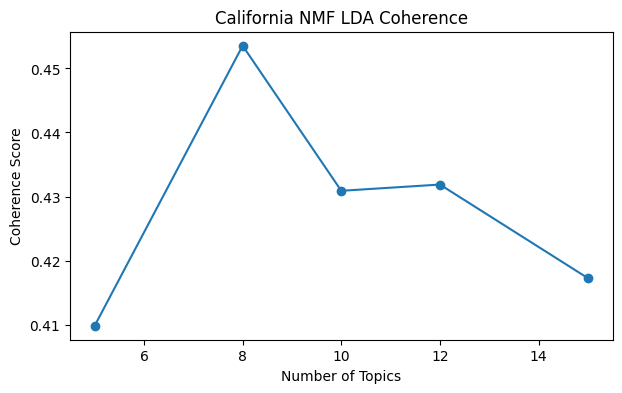

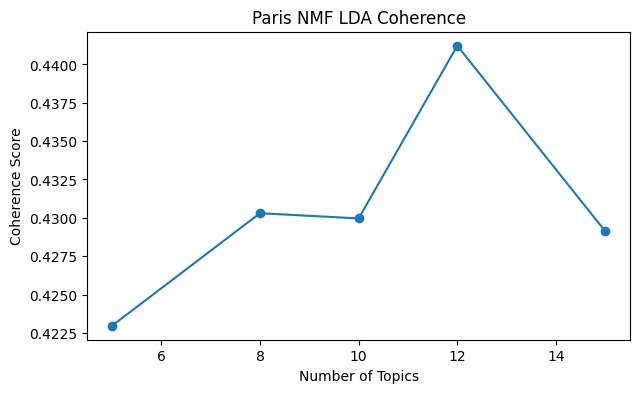

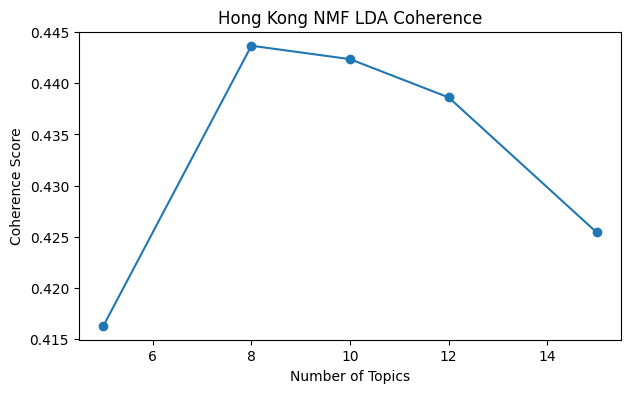

In [ ]:
# Plot NMF coherence scores
k_values = [5, 8, 10, 12, 15]

plot_coherence(k_values, california_nmf_coherence, "California NMF")
plot_coherence(k_values, paris_nmf_coherence, "Paris NMF")
plot_coherence(k_values, hongkong_nmf_coherence, "Hong Kong NMF")

### Final NMF Topic Selection

Based on the NMF coherence scores, the optimal number of topics for each park is:
- California: k=10
- Paris: k=8
- Hong Kong: k=10

These are the same as the optimal topics from the LDA model results so we can directly compare both models.

In [ ]:
best_k_nmf = {
    "California": 10,
    "Paris": 8,
    "Hong Kong": 10
}

final_nmf_models = {
    "California": california_nmf_models[best_k_nmf["California"]],
    "Paris": paris_nmf_models[best_k_nmf["Paris"]],
    "Hong Kong": hongkong_nmf_models[best_k_nmf["Hong Kong"]]
}

final_nmf_matrices = {
    "California": california_nmf_matrices[best_k_nmf["California"]],
    "Paris": paris_nmf_matrices[best_k_nmf["Paris"]],
    "Hong Kong": hongkong_nmf_matrices[best_k_nmf["Hong Kong"]]
}

print("Final NMF reconstruction errors:")
for name, model in final_nmf_models.items():
    print(f"  {name}: {model.reconstruction_err_:.4f}")

Final NMF reconstruction errors:
  California: 133.0649
  Paris: 111.7872
  Hong Kong: 93.9487


In [ ]:
def show_nmf_top_documents(df, nmf_matrix, topic_num, top_n=10):
    """Return top documents for a given NMF topic index."""
    temp = df.copy().reset_index(drop=True)
    temp[f"Topic_{topic_num}_weight"] = nmf_matrix[:, topic_num]
    top_docs = temp.sort_values(by=f"Topic_{topic_num}_weight", ascending=False).head(top_n)
    return top_docs[[f"Topic_{topic_num}_weight", "Review_Text"]]

In [ ]:
for t in range(best_k_nmf["California"]):
    print(f"\n===== California NMF Topic {t} =====")
    display(show_nmf_top_documents(california, final_nmf_matrices["California"], topic_num=t, top_n=10))


===== California NMF Topic 0 =====


Topic_0_weight  \
2615         0.088202   
19248        0.083279   
17462        0.082628   
17051        0.080780   
625          0.080417   
12373        0.079419   
13385        0.078706   
11271        0.078598   
10594        0.077605   
14295        0.077213   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   


===== California NMF Topic 1 =====


,Topic_1_weight,Review_Text
4821,0.132968,We were in Disneyland in 2002 and then in 2016 and we found it much more fun when the kids were young in 2002.
5415,0.129145,I recently went with no kids and I had so much fun on my own . its was just as much fun for me as it is for kids... Love this place and will be returning in August!
17830,0.123954,Love the rides and to see kids having fun is just the best.
16918,0.119037,Good fun kids enjoyed it and they liked it. Food in Disney land is expensive
8789,0.118661,A fantastic place where kids can be kids and adults become big kids in a mystical world which is clean friendly and of course fun.
5784,0.114952,"My little kids, my ig kids, who am I kidding, we all love it! We have such great memories here no matter what our ages are"
8525,0.113481,"My family and I went here on our vacation and it was amazing. It was like I was a little kid again, seeing all the characters I grew up on. My kids also had fun with all the rides and the mascots walking around just waiting for you to come and take pictures with them."
8475,0.113464,Long lines. Very expensive. Kids love this place along with adults who act like kids. Fun for the whole family.
7947,0.112330,My first time at the age of 39 and I loved it!Wish I was a kid there as it is the ultimate fantasy place for kids.Had only one day there but you could be there for days. If you have kids do everything possible to take them there. If you don't have kids still go and be a big kid for the day!
18984,0.112168,My wife and I honeymooned at Disneyland and had a lot of fun it is said to be a geat time for families with kids but also a lot of fun for just two!



===== California NMF Topic 2 =====


...

,Topic_7_weight,Review_Text
16319,0.144942,"I have been to Walt Disney World in Florida many, many times and was very surprised how small Disneyland was. I do enjoy hopping from one park to another in Florida and there is only DisneyLand park and the California adventure (didn't go there) in California."
12734,0.137735,"This was my first visit to Disneyland. I grew up in Florida, and know Disney World like the back of my hand, so it was fascinating to finally go to Disneyland. The two places are very different, but of course a bit the same. Its like two great artists painting the same thing. The main differences are in the size and feel . Disneyland is much smaller and only two parks (Im counting California Adventure in this review, as to aid in the comparison). Disney World is four parks (not counting the water parks and other attractions). Disney World also is more of a self contained resort, with a ton of Disney owned hotels. Disneyland feels a bit more like a traditional theme park. The positives of this is that Disneyland, being much smaller, is much easier on the feet and easier to get around in. Its not as jaw dropping in terms of spectacle as Disney World (with maybe the exception of Cars Land at California Adventure, which they did a smashing job on recreating Radiator Springs), but most of the attractions are the same, and some, such as Space Mountain, are much better at Disneyland than Disney World. Cars Land makes California Adventure a must see, and if your kids like the Cars movies as much as mine, it is really awesome. One positive of Disney Land is that its much easier to do a non Disney hotel. In Disney World, I almost always go for an on site Disney Hotel its part of the experience. At Disneyland, its not essential. Also, the meal plan at Disney World is a serious consideration. At Disneyland, with all the restaurants around, its not needed.A few other things we noted. First, while the cast members at both parks are great, the characters at Disney Land were much more interactive and spent more time with the kids. The climate in California is much more comfortable than Florida. You may need a light jacket in the morning, but it was nice not sweating to death in the high temperatures and humidity of Orlando. One negative is getting from the airport to the parks. LAX is not fun, and the lines are so long. Give yourself plenty of time to arrive early. Took us over an hour to get through security. LAX is about an hour away. I know that there are other airports that are closer. Transport is not as nice, quick and easy as the Disney Shuttle service is from MCO to Disney World.Not a negative, but just a note the vast majority of fellow visitors to the park are from the LA area and the west coast. I think most people in the rest of the US go to Disney World. I think they are missing something. Its a different experience smaller, more intimate, more compact, but still with that Disney quality. I don't think either Disney World or Disneyland is better or worse than the other just different....and that difference is good. Which I would choose would depend on my mood and my budget. If I want total Disney resort immersion where I can totally forget the rest of the world exists for my entire vacation time, including hotel and dining, and I want big spectacle, and I have a nice budget and an entire week off (so I could hit all the parks), I would lean towards Disney World. If I wanted a Disney experience in a more easy to consume size, had a small budget and or less time off, and maybe still want to keep one foot back in the real world , then Disneyland is the choice."
9629,0.127411,"We were so excited to go to the 'original' after many trips to Disney World. There are a lot of positives and amazing things to see. We loved the Small World ride better at Land than World.However, the experience overall was not as 'magical' as a visit to Disney World is. Maybe it's because the people who work at World are often from all over th


===== California NMF Topic 8 =====


,Topic_8_weight,Review_Text
13790,0.278997,"The happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth, the happiest place on earth :D"
7920,0.209188,Disneyland the happiest place on earth! You will be the happiest person on earth as soon as you pass the front gates!
18589,0.205455,Disneyland is great. What else can you say? It is the Happiest Place on Earth. Just go.
13951,0.202462,Best Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kidsBest Place on earth for kids
17449,0.195792,"I loved everything! :) It's the Happiest Place on Earth, you know?"
6492,0.193351,It's Disneyland it's literally the happiest place on earth. It's also the most crowded place on earth. But it's still the most amazing place ever. GET OVER IT!
8282,0.191001,The happiest place on earth. The lines are the longest place on earth but the fireworks are spectacular.
8133,0.183598,"Its Disneyland ! ! ! What more can be said. As Walt said it would be, The happiest place on earth ."
3309,0.183462,"I don't believe that anyone can say anything bad about the happiest place on earth and that is exactly what it is 'the happiest place on earth'!! It does not matter what age you are, everyone will have an amazing time. We love Disney"
17757,0.168086,It's Disneyland. The happiest place on earth. I really enjoyed the new Indiana Jones ride.



===== California NMF Topic 9 =====


,Topic_9_weight,Review_Text
18295,0.206335,"Love everything about Disneyland. Great rides, great shows, great food."
16938,0.167158,What is there not to like about Disneyland? Rides were great. Weather was great. Loved it.
10899,0.166097,We had a fantastic time at Disneylad. The weather was great and my family had a great imd on all the rides.
226,0.158985,"Great time clean, friendly, user friendly, great food, great service, great staff, Well lit, great layout"
18016,0.156170,Great fun and my daughter loved it. The staff were great and the whole experience was very good and very well done. Food not great.
13872,0.153379,"There is a lot to do in Disneyland. There are great rides for the young and olf, the good is great as well."
16828,0.150456,Great time with lots of shops and great food. Had a blast.
5970,0.149335,Great great great time! The only downside is the food and the waiting times in line. Californian adventure park was really fun too.
1549,0.147607,We had a great time at Disneyland. We went on Easter so it was busy from about noon through 6pm but that s about it. Great times. Great staff. Great everything truly the happiest place on earth.
425,0.146792,Great Family Vacation. Great for all ages. We had 13 Family members from age 3 to 77. Was great for everyone.


In [ ]:
for t in range(best_k_nmf["Paris"]):
    print(f"\n===== Paris NMF Topic {t} =====")
    display(show_nmf_top_documents(paris, final_nmf_matrices["Paris"], topic_num=t, top_n=10))


===== Paris NMF Topic 0 =====


Topic_0_weight  \
13031        0.119100   
12961        0.106634   
9497         0.105710   
13024        0.104900   
13039        0.102962   
3930         0.101994   
6374         0.100912   
9163         0.099040   
12954        0.098693   
13309        0.098680   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   


===== Paris NMF Topic 1 =====


,Topic_1_weight,Review_Text
5415,0.149697,"The parade and firework shows are a must see in disneyland park, the rides are amazing and the castle is something else to see and even better at night."
1974,0.140632,"This is a very happy place to take young children, very magical especially the fireworks and light show at the castle every night at 10,it was amazing and a must see. There are lots of rides, shops and restaurants plenty of things to do."
5863,0.139013,there was so much to do the rides were amazing the parades were magical and the show in the evening at the castle were pretty spectacular never seen anything so amazing it makes you cry
8726,0.137343,I came with 4 children aged between 6 and 15 we all had a great time queues were not too long. The magic hours you get if you stay at one of the park hotels are well worth it the parade is great the end of the night show is amazing but for all these things get there early for the best view. If you get to go for a few days the times when the parade and the end of the day show are the best for queue times to be low so see the show one night and do the rides the nextWe also had half board and the good was amazing in the buffet restaurants Steve
11658,0.134492,The 20 years special parades were really good and the light and fireworks show on the castle was one of the best Disney attractions I have seen. Amazing. Only problem was the night time parade started at 10.15pm and the light show at 11.00pm. You got back to the hotel after midnight which was very late for our 6 year old granddaughter.
8196,0.131147,"Christmas at Disneyland Paris is Magical & Entertaining. The lovely song, wonderful parade and evening show on the castle with the lighting and firework make is completely magical to see. we had a fantastic time and would definitely go again!!!"
3366,0.129658,"excellent day out great for all ages veery magical with the shows & parades, the fireworks at the end of the day are fantastic"
5822,0.127766,Fun rides and plenty of resterants and snack bars the character parades are a must to see very magical and at night when the castle lights up its fantastic
6453,0.126502,"Amazing place and very magical! Wait for rides was not too bad, fast pass are a must. Lots of characters about and an amazing parade!"
7917,0.123841,Disney is a must do in December. I went between the 19 24th last year and it was wonderful. Everything is lit up and they even make snow! All the shows and parades are spectacular and the park is open late every night. Disney is magical at Christmas and is a must see. Wouldn't go any other time.



===== Paris NMF Topic 2 =====


...

,Topic_5_weight,Review_Text
2502,0.256964,"great fun, great characters, great shows and parade, great staff, very clean. you will want to come again"
11867,0.210371,The atmosphere was great. Parades great. Rides great for both young children and adults
13139,0.201139,"I had a great day out at Disneyland, being 20 and having no kids with us I wasn't sure what to expect, but it was great."
13149,0.195420,"Great Rides, great parade, good (halal) food. Great day with the lot."
7382,0.194970,Great place but take plenty of money food and drinks very expensive great rides great atmosphere just loved it .
2694,0.186207,"Although it was raining during our stay, we had such a great time and visit to the park. Its Disneyland and it great."
8757,0.166221,"We travelled last week, it was great. The rides were great and there was a great number of things to do inside the park. The downside was the great number of people inside the park, meaning greatly long queue times of over an hour for some great rides. The park is great in size so bring comfortable shoes so your feet don't grate inside them. The mark up on food was great however, you could easily spend 40 for 4 people to have lunch at the cheapest food outlets, the food was not that great."
10580,0.163546,It was just as expected very magical and great fun. Loads to great rides and some great shows too. We took our 4 and 8 year old and they both really enjoyed it. Well worth a vist.
10334,0.158154,"Atmosphere, atractions and shopping all great. Just wonderful to sit and watch. Great for people watching and great for fun."
8026,0.158116,"IF you visit Paris do not miss disneyland ,it was great expreance and i am suggestioning for everybody,we have really great time and enjoy it."



===== Paris NMF Topic 6 =====


,Topic_6_weight,Review_Text
7457,0.130888,"Being avid fans of Disneyworld, etc in Florida (and yes, i know we're not reviewing those parks), we were mortified with the staff and their lack of emotion, smiles, pleasantries, whatever you want to call it. At the end of the day, these are still disney parks and i would like to think that the 'magic' happens here too! Sadly, for us, it certainly did not. The staff, apart from the odd 1 or 2, were dreadfully rude. They looked at us as if we had 2 heads when we tried to purchase order anything (and we speak English)!! It also seemed to be 'the norm' to stand in a queue, as you do, for at least 30 minutes, to go on a ride, only to have families of French people being let in sneaking in towards the front of the queue and pushing or should i say FORCING their way in so they didn't have to wait. We noticed a lot of different people 'kicking off' because of this and getting very agitated. This kind of thing should all be monitored by park staff so that tempers do not rise. WE made our stay lovely, the park staff certainly did not, and at least we can say we've experienced it, even though we NEVER will again.The rides were ok, but again, due to lack of emotion by the staff, it all seemed to lack that 1 special thing ................ customer service. The other minor irritation i have, we are smokers and at the very start, looked on the park maps for designated areas, however, no one else did!! People strolling around smoking, sitting having a coffee and smoking, WHERE THEY WANTED TO, so, we pulled up a seat, had a coffee etc, lit a cigarette and were told by yet another miserable human being (staff) that we had to move on!!! We apologised profusely and moved and then, people sat in the exact same seats, at the exact same table, and did exactly what we were told not to do, and the member of staff stood and watched them ............. and let them carry on!!!1 thing to say Disneyland Paris. ............... train your bl@@dy staff!! Courtesy goes a long way, and good customer service brings people back. END."
8407,0.117809,"As Disney fans, my family have visited Florida for our main holiday over the past 5 years we decided to go to Paris for a couple of days at the beginning of October as we had booked a week in the Paris region anyway. I still cannot understand how 2 Disney parks can be so different I assumed that the Disney brand would ensure that the experience would be the same, however this is clearly not the case. There were moments where we agreed that it felt like Florida (walking up Main Street and during the parades) but it ended there. The staff are generally so miserable, rude and the service you receive is terrible. Customer service is not a strong point here. I felt like I spent 2 days walking through a cloud of cigarette smoke people smoke constantly, everywhere I didn't like the fact my small children were breathing second hand smoke every time we stepped outside a building (it really was quite bad). The food in the park was generally terrible (although we didn't visit the very expensive restaurants you do still expect a level of quality). I guess we are used to the good quality food in the USA. Service was slow despite being off peak at one point I queued 40 minutes for ice creams as there were 2 members of staff but only 1 very slow person working! Very few characters to meet and greet, we waited an hour to meet 1 princess!! Again this might seem normal to some people but when you have visited Disney in Florida it seems totally unacceptable.Disneyland Paris comes across as a very tired park it needs work and money spending on it. Rides breaking down all the time, things not working correctly, many things need painting and revamping, its a bit grubby and dirty the TOILETS ARE DISGUSTING!!!! Its the small touches like the princess meet and greet hall had features held together with duct tape this would never happen in Florida where everything is pristine!! The run away mine tra


===== Paris NMF Topic 7 =====


,Topic_7_weight,Review_Text
8583,0.222454,Just arrived home from euro Disney and we can't wait to go back. I went with my 10 year old daughter and she was amazed by everything!! Loved the rides!!Loved the hotel!!Loved the food!!Love Disney!!!!Now saving to go back again next year if possible and I am now a Disney loving grown up.....gotta love it
6894,0.206765,"We have 2 kids in the age of 8 and 10, the 8 year old just love it 3 while the 10 year old just love one attraction"
2174,0.181823,It is really good. My children love it they love the parades the characters they meet and some of the rides. They just love the Disney experience and the magic.
7626,0.175051,Disneyland paris is magical loved everything about it apart from the queues booked for next year loved it
3418,0.164115,"No matter what age you are, you will love this place. Absolutely magical. Brought my 8 year old daughter and she loved every minute. The rides and the parades are just fantastic. Seeing is really believing. We will be returning again very soon..."
11300,0.163515,"Love, loved loved it!!!! So want to go back, took all tips off this site and we had an amazing five days, canny wait to go back,."
5488,0.160295,I love Disney! My kids love Disney so this was perfect we absolutely loved every minute. The firework display at 10pm was amazing! Worth staying up for!
3783,0.154717,"Was here with our 3 year old daughter, She loved the castle and loved meeting the characters once we eventually did, the 45 min queuing time we did not enjoy"
5581,0.154193,"Love it, love it, LOVE IT! Oh did I mention, I love it? Great family day out!! If you get magic hours, use it! Start from the back and work your way forward! As soon as you walk into the park you'll have Micky &...More"
2541,0.153767,Love it here so much. Such a brilliant atmosphere. Used to come here quite a lot when I was younger with my family. Absolutely love pirates of the Caribbean ride! Love everything about this place!!


In [ ]:
for t in range(best_k_nmf["Hong Kong"]):
    print(f"\n===== Hong Kong NMF Topic {t} =====")
    display(show_nmf_top_documents(hongkong, final_nmf_matrices["Hong Kong"], topic_num=t, top_n=10))


===== Hong Kong NMF Topic 0 =====


,Topic_0_weight,Review_Text
8983,0.119781,"really good to visit but a bit small compare to other disney over the world, rides are for small children but worth to visit"
730,0.114416,"This Disneyland is the smallest one compare with all others over the different parts of the world. However, it's amazing for Hong Kong, such a small place, to has a Disneyland. It's fun if you have not been any other Disneyland before. Don't expect too much and don't try to compare this one with others over different side of the world. I may say all the Disneyland theme parks are about the same, just different sizes and one have more rides than the other."
6772,0.104957,"I've been to both Tokyo Disneyland and Hong Kong Disneyland. But there's one thing that I like about Hong Kong Disneyland. Because of its small size, the attractions rides are very close to one another. You don't have to walk very far. And I think it's big spend one day in a Disneyland."
3245,0.101384,"Not like the Disneyland in Tokyo, which is also good for young people, I would think the HK one is much smaller and for children only."
2715,0.095075,"Disappointing because it's a bit small. If you've been to any other Disney theme park I think this one wouldn't compare favorably. On the plus side, of you are Disney mad and have small kids it sure it would be fun!"
8122,0.094927,"I'm a huge Disney fan and I've been lucky enough to visit both Disneyland Paris along with Disney world in Florida over 20 times. I also worked an internship in Disney Florida. So yes, I'm a bit of a Disney geek and I was particularly excited to see what Disneyland Hong Kong had to offer. I knew that this park was small but I was pleased to find it still had the Disney magic. The layout is like a small scale of Magic Kingdom in Orlando, main street leading on to the castle and each 'land' going off from the centre point like a wheel. There were many places that were versions of the Florida park, such as crystal palaces restaurant, the jungle cruise, Small World etc. This is not the park to come to for thrilling rides, actually Space Mountain was the biggest disappointment here for me, it wasn't half as good as the Orlando one! Boo! However, the attractions are all well done, maintained to a great standard and have that same level of 'magic' that we know and expect from Disney!This is really only a one day attraction. You could stretch it out to two days here but after that you'll probably start to get a bit bored even if you're a Disney fanatic like myself :D"
8783,0.093385,"It's a small world after all. Unlike Disney World, you can do in a day and never go back. It was very sexy compared to Orlando."
7967,0.091000,Too Small and Overcrowed with Obnoxious Visitors from the world's most populous country who have no manner and don't know what civilization mean. The place itself is very small (too small) compared to other Disney property around the world
4399,0.090918,"I've only been to two Disneylands: Hong Kong and Paris. Though HK Disneyland is smaller, I think it's much better than Paris Disney. I want to go there again one day."
8123,0.090303,"After visiting Walt Disney world in Orlando 3 times we expected Hong Kong Disneyland to be on those same lines but unfortunately we found the park to be quite small compared to the one in U.S.A., nevertheless if you want to enjoy a fun day with the kids I would recommend getting a one day pass as you will have enough time to explore the park ."



===== Hong Kong NMF Topic 1 =====


,Topic_1_weight,Review_Text
2764,0.188976,"The most amazing experience in Hong Kong is this place which is a must visit for all ages. The afternoon parade, night parade and fireworks are highlights og the place. Lion king show is also very good.All the rides are quite good."
5204,0.159268,I recommend to spend a full day. Don't miss the 'Parade' and the Fireworks show at the end of the day. A must watch for everyone who enters Disneyland.
982,0.158985,"Its fanstastic. Specially for people who come for a holiday with kids, you must visit Disneyland and stay in the Park area itself. You can cover all the rides and shows if you stay for 2 days. Besides the rides, you must try and see all the shows currently going on. The Lion King show was fabulous. Dont miss the parades in the afternoon as well as night parade as both are different. Unfortunately during our visit the castle was closed and there were no fireworks. Try to cover Tomorrowland and Adventure land 1st as there is maximumn waiting time there."
8437,0.152666,"who doesn't love Disney? Golden Mickey is a MUST SEE SHOW! and all the parades and fireworks, it's like we're in a different world..."
7722,0.148604,"I went to Hong Kong Disneyland with my brother and sister on Jan 2013. I think it was a good time to go Disneyland Hong Kong in Jan. Jan is off peak season, not crowed , windy and won't feel not hot especially when you queuing for the show under the sun. This must be consider when you have kid and old folks. Hong Kong Disneyland is small compare with other Disneyland but , it does offer some great attractions Space Mountain roller coaster, Festival of the Lion King stage show, Golden Mickey's stage show, Mickey's Philhar Magic 4D show. Like 3 of us,we are all adults ,hence most of the games are not suitable for us. We just take photos everywhere and we felt we were back to childhood times when we saw those Cartoon characters. I suggest must watch all the shows. it's nice. I love all, the Festival of the Lion King and Golden Mickey are opera. But Golden Mickey only show in Cantonese (I can't remember got English subtitle on the screen not). The show i like most is the 4D show. It's amazing ! I smell the pastries smell nice. Got bubbles & water splashing around you...Its fantastic. Suggestion: We spent whole day in Disneyland.The fireworks show start at 8PM . Please don't forget to find a best place before the show start. We sat on the floor in front the Disney castle. We never watch until the show ended because we consider of the crowd .We worry about the train very crowded when the show end hence we leave on 10mins before the show ended."
5953,0.147346,Whilst we was in China we went to Disneyland Hong Kong and it was amazing for our children. It isn't the biggest disney park but our children are only young and they loved it. The live lion king show is a must and so is the 4D show. Plus we stayed for the late precession show and fireworks which was great at night. Great day out.
5524,0.146791,"nice place. 3 things that u should not miss is the evening parade, the night parade and the closing fireworks show. be sure to check the timing because sometimes it does change."
6014,0.146686,"For all the Disney Princess lovers this place is your dream destination. Good rides. The best part are the parades and the various shows, you can miss the rides but make it a point not to miss the parade and the shows. Go well planed for the show's"
360,0.146438,"My kids very enjoyed it especially Mytic Monor, Lion King Show and Story Book Show. The show was superb and we had wonderful time in Hong Kong Disneyland."
843,0.144431,"We enjoyed our visit to Disney Land, the parade, the shows (lion king is a must see) and all others..but just a little bit disappointed because they did not have firework show at that time. Cinderrella's castle is under contruction. But all in all our experience was pretty good."



===== Hong Kong NMF Topic 2 =====


...

,Topic_7_weight,Review_Text
7657,0.210740,Wow ... Fun lots to see and lots of people. The train ride was fun and interesting seating and handrail.
2860,0.205009,"Disneyland a fun place to stay, well kept, lots of activities and always a fun place to be with kids of all ages."
541,0.177301,I had awesome fun at Disneyland they had a fun Halloween show with Mickey Minnie goofy dancing. Had A great fun day there.
7201,0.175108,"If you do visit Hong Kong, do visit Disneyland. It relieves your childhood & FUN FUN FUN! Enjoyed the rides, love the shops & love the characters!"
7954,0.174826,"Perfect for the little ones in your life. The park was lots of fun, easy to get around and lots to see and do for a fun filled day.Most rides were suitable for children, no long lines on the day we were there. Had a great time."
6530,0.168309,"fun, fun and fun.. what a place.. wonderful.. enjoyed full day.. weather was favourable in october.. all rides and shows very enjoyable.. light show at the end of the day too good.. must visit once.."
2981,0.165188,definitely a place to visit when you are in Hong Kong! Lots of fun ride. However most of the rides are for kids or not so thrilling
6688,0.164120,"It's the first Disneyland I've ever visited and I had lots of fun. It's not too big , so you can enjoy it in a day."
7434,0.159980,Disneyland HK had all the fun of the other Disney parks without the lines. 5 min for Space Mountain. Small park but full of fun.
8411,0.159899,"in normal Disney tradition, everything well maintained and fun for kids. Not up to Orlando but a whole lot of fun nevertheless."



===== Hong Kong NMF Topic 8 =====


,Topic_8_weight,Review_Text
1861,0.139114,This is one of the smallest Disneyland's however it was still quite expensive for a one day visit. We went mid week to avoid the weekend crowds however it was still very busy. The queues for the rides were long with an average wait of about 30 minutes. I would recommend going when it just opens and doing the popular rides first as the queues will be shorter then.
3034,0.138093,"Disneyland Hong Kong is a very small park compared the ones in the U.S. , very crowded and with very long queues for each attraction."
2840,0.135317,"We had 2 young kids under 5 with us. Queues were long but moved relatively quickly considering the length of them! Staff were friendly & efficient. As the gates opened people sprinted for the most popular rides, I would say head (fast!) to the ride you MOST want to do as the queues got longer as the day progressed, the first 2 rides we did we didnt have to wait for than 3 minutes to get on but when we got to the more popular rides we waited 30 minutes. Food was relatively good, no long waits. The shows were a great way to get away from the swarming crowds & hot weather. We spent 2 days going through, which I would recommend due to the crowds & being able to get your moneys worth on the rides. Plenty for the younger kids to do see. If staying at the Disneyland hotel, be sure to be outside waiting for the complimentary bus early as the crowds for that were incredible!"
4690,0.133628,We went on a Wednesday and we really enjoyed ourselves. The queues were not long so we didn't have to wait that long to get on a ride. This time we stayed for the night parade which was so much better than the one in the afternoon and the fireworks were lovely too. Definitely worth going as they have rides for all ages and everyone can enjoy and have a good time. I would suggest going on a week day to avoid the long queues and crowds
3674,0.124617,"We visited HK Disneyland in the month of July, I'm guessing it was school holidays in neighbouring China, so there were hoards of Chinese tourists. The queues were Long and we had to wait a minimum of 45 minutes for each ride, the queues were very badly managed by the Disneyland authorities. Some of the quiet were suffocating as there were no fans even and hardly any place to stand due to the winding queues. To add to it, the Neighbouring crowd were very noisy and had total disregard for others, and were happily cutting queues at every opportunity without any guilt or consideration for young kids who were standing on the line.We managed only a few rides for our 7 year old Daughter due to the Long queues, however the evening parade and the fireworks display was a treat to watch and made up for the day's misery."
6497,0.123373,"Many many tourists from all over the world. Crowded but all themed parks are crowded.Long long queues and manageable. The park is not very huge. Very manageable. At 3pm you can watch the parade and if it rains, they will change it to a shorter parade.Shopping is nice at Disneyland. The shuttle to the hotel is quite far away.Overall, nice"
7324,0.120284,We took our 3 and half year old to Disneyland on the first Friday after the Chinese New Year. As most people were still on their holidays we were expecting it to be packed out. It was very crowded with queues at all the attractions....More
7804,0.120108,Long queue for each ride. At least 40 mins queueing. Advise to avoid china holidays when going Hongkong
5854,0.118090,"There was one good ride we did, the rest was kids stuff. Definitely don't go in the weekend, many people and long queues..."
2205,0.116062,"one of the best tourist attraction in Hongkong. There are lot of Disney characters, to take pictures. better to go early in the morning to avoid any queues. after 12 noon it is getting really crowded and long queues. it is about 20 minutes from airport to Disneyland, from taxi. Pretty amazing experience."



===== Hong Kong NMF Topic 9 =====


,Topic_9_weight,Review_Text
176,0.140012,Awesome feeling and great experience. Really enjoyed a lot with family. Would love to visit the place again and again
5234,0.132437,Best thing was that we enjoyed it ourselves beacuse our daughter enjoyed it too much! It was like a dream for her!
9234,0.130215,"we all enjoyed rides and food here, we thought we may not enjoy but it was main attraction for my son we went here and value for money and time..... he will never forget the experience and we would love to come here again"
1222,0.127944,My 1 year old nephew enjoyed exploring disneyland. I loved my stay with my family and will visit again for sure!
8048,0.124560,Brought my wife and Daughter here and we really enjoyed the happiest place in Hong Kong. my daughter really enjoyed the meet and greet with Mickey and Friends. she also enjoyed the different kiddie rides and shows. unfortunately it closes at 8PM ( a bit early) and we enjoyed the fireworks.
616,0.123877,We love this place. My 6 years old daughter and a one year old son is enjoying themselves in Disneyland. Most of the rides has no ages restriction like other theme park. We bought 2 days entry ticket and well spend for both days.
2705,0.121585,"my family really enjoy our trip in hk, speacially hk disneyland it brings out the child in me, although it was raining when we went there, it does'nt stop to enjoy the place, we loved the fireworks display beautiful & breathtaking"
8821,0.120766,"Went there last March 10, 2012, super loved the place, very magical. Am super happy!! felt like am a child again...i enjoyed it a lot. Worth visiting with your family esp children... will surely come back again next year with my family because i came with my friends."
338,0.117219,"I love disney character since I was a kid, and I brought my daughter here and she loves every part of it. I love the parades, every different seasons too. It always makes me goosebump and love the music. I didn't make any much photos with the character but my daughter did. Worth to pay for the ticket for a year pass. This place is a happiest place on earth for me!"
9512,0.111837,"Myself and my husband and our 1year old baby visited Disneyland in early November. We stayed in the Disney Hollywood Hotel and spent a day in the park. We loved it! We have visited Disney World in FL and have to say that everything about the Hong Kong park was great. The park was spotless clean, the staff were very friendly, no queues and plenty of things to do and see. Our son loved it would definitely recommend a day or two visit for families with young children.This is not Disney Orlando, California, or Paris, but we loved it. Having been to Orlando, this has very few of the big rides, but it fewer lines and less crowds. I would not recommend this for teenagers, but for my 1 year old it was a blast! No massive lines means happier children and happier parents. We went on a tuesday so the crowds weren't too bad.We enjoyed the fireworks that night and we felt we were children again...Overall, loved hong kong and would definitely love to come back."


In [ ]:
def compare_models(lda_model, nmf_model, vectorizer, name, top_n=10):

    words = vectorizer.get_feature_names_out()

    print(f"\n===== Model Comparison: {name} =====\n")

    n_topics = min(lda_model.num_topics, nmf_model.n_components)

    for topic_idx in range(n_topics):

        lda_words = [
            word for word, prob in lda_model.show_topic(topic_idx, topn=top_n)
        ]

        nmf_words = [
            words[i]
            for i in nmf_model.components_[topic_idx].argsort()[::-1][:top_n]
        ]

        print(f"Topic {topic_idx + 1}")
        print("LDA:", ", ".join(lda_words))
        print("NMF:", ", ".join(nmf_words))
        print()

In [ ]:
compare_models(
    final_lda_models["California"],
    final_nmf_models["California"],
    california_tfidf_vec,
    "California"
)


===== Model Comparison: California =====

Topic 1
LDA: food, eat, water, bring, good, drink, snack, lunch, restaurant, expensive
NMF: crowd, people, would, one, get, take, back, long, ticket, go

Topic 2
LDA: world, florida, disneyworld, much, california, better, magic, smaller, walt, original
NMF: kid, fun, lot, much, enjoy, age, family, adults, take, character

Topic 3
LDA: great, love, kid, fun, see, enjoy, year, family, old, make
NMF: pass, fast, use, early, system, hopper, california, adventure, app, popular

Topic 4
LDA: show, parade, fireworks, see, street, main, night, fantasmic, watch, seat
NMF: mountain, space, jones, indiana, splash, star, pirate, thunder, haunt, tour

Topic 5
LDA: pass, fast, use, one, get, early, crowd, ticket, plan, long
NMF: love, year, every, old, back, everything, come, go, daughter, trip

Topic 6
LDA: mountain, space, pirate, jones, indiana, splash, star, california, tour, haunt
NMF: always, clean, friendly, staff, cast, helpful, members, magical, ne

In [ ]:
compare_models(
    final_lda_models["Paris"],
    final_nmf_models["Paris"],
    paris_tfidf_vec,
    "Paris"
)


===== Model Comparison: Paris =====

Topic 1
LDA: see, parade, character, great, show, kid, love, queue, would, children
NMF: food, hotel, take, stay, expensive, drink, eat, good, book, price

Topic 2
LDA: food, hotel, eat, drink, good, expensive, stay, euros, meal, price
NMF: show, parade, amaze, see, character, magical, fireworks, light, night, meet

Topic 3
LDA: people, smoke, staff, push, rude, one, children, say, french, front
NMF: mountain, close, space, thunder, big, pirate, attractions, jones, indiana, world

Topic 4
LDA: staff, florida, close, experience, would, seem, many, disappoint, look, french
NMF: pass, fast, ticket, queue, use, long, one, buy, system, hours

Topic 5
LDA: hotel, take, get, one, book, back, leave, would, could, minutes
NMF: kid, enjoy, adults, fun, like, attractions, family, experience, age, much

Topic 6
LDA: ticket, pass, fast, one, food, buy, long, take, attractions, queue
NMF: great, fun, lot, food, family, staff, clean, friendly, age, expect

Topic 

In [ ]:
compare_models(
    final_lda_models["Hong Kong"],
    final_nmf_models["Hong Kong"],
    hongkong_tfidf_vec,
    "Hong Kong"
)


===== Model Comparison: Hong Kong =====

Topic 1
LDA: people, staff, queue, would, crowd, even, chinese, say, one, think
NMF: small, one, world, much, compare, smaller, would, still, like, disappoint

Topic 2
LDA: mountain, space, show, small, world, jungle, cruise, mystic, pooh, lion
NMF: show, parade, fireworks, night, lion, king, miss, must, see, watch

Topic 3
LDA: weather, hot, rain, enjoy, good, summer, game, halloween, crowd, bring
NMF: kid, adults, young, heart, must, age, like, nice, older, little

Topic 4
LDA: ticket, food, buy, take, water, bring, hotel, pass, price, hkd
NMF: land, mountain, space, toy, grizzly, mystic, story, manor, gulch, new

Topic 5
LDA: character, take, see, experience, kid, enjoy, parade, fireworks, come, make
NMF: great, family, spend, easy, smaller, still, experience, big, train, clean

Topic 6
LDA: show, parade, fireworks, night, miss, king, lion, watch, must, good
NMF: good, food, expensive, price, staff, nice, drink, quite, inside, water

Topic 7

## Step 6: Topic Interpretation and Naming

#### LDA Topic Interpretations
##### California (k=10)
| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *food, eat, water, bring, good, drink, snack, lunch, restaurant, expensive, dinner, lot, price, take, bottle, walk, shop, restaurants, meal,"breakfast* | *Food Planning and Cost Tips* |
| Topic 2 | *world, florida, disneyworld, much, california, compare, wdw, small, like, different, attractions, one, adventure smaller, better, compare, original, magic, walt, orlando, kingdom* | *Disneyland vs Disney World Comparisons* |
| Topic 3 | *great, love, kid, fun, see, make, family, enjoy, year, old, always, amaze, experience, trip* | *Family Trip Experience* |
| Topic 4 | *show, parade, fireworks, main street, night, fantasmic, watch, seat, view, spot, light, castle* | *Shows and Nightime Experience Entertainment* |
| Topic 5 | *pass, fast, get, early, crowd, ticket, plan, long, time, days, minutes, stay, open* | *Queue Strategy and Park Planning* |
| Topic 6 | *mountain, space, pirate, jones, indiana, splash, star, tour, haunt, matterhorn, thunder, caribbean, mansion, small, world* | *Classic Rides* |
| Topic 7 | *years, new, annual, season, pass, always, since, still, crowd, change, summer, week* | *Repeat Visitors and Passholders* |
| Topic 8 | *christmas, holiday, halloween, party, decorations, special, theme, beautiful, haunt, event, candy* | *Holiday/Seasonal Events* |
| Topic 9 | *tell, ask, cast, picture, character, give, meet, daughter, son, members* | *Cast Member Interactions* |
| Topic 10 | *people, crowd, price, pay, money, think, disappoint, experience, break* | *Price Sensitivity and Crowding concerns* |

##### Paris (k=8)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *see, parade, character, great, show, kid, love, queue, would, children* | *Experience for children* |
| Topic 2 | *food, hotel, eat, drink, good, expensive, stay, euros, meal, price* | *Expensive food, drinks, and hotels!* |
| Topic 3 | *people, smoke, staff, push, rude, point, children, queue* | *Bad Experience: rude staff* |
| Topic 4 | *staff, florida, close, experience, would, seem, many, disappoint, better, expect, time, break* | *Unmet Expectations and disappointing service* |
| Topic 5 | *hotel, take, get, one, book, back, leave, would, could, minutes, bus, queue, make, walk, arrive, room* | *Hotel Logistics and Transportation* |
| Topic 6 | *ticket, pass, fast, one, food, buy, long, take, attractions, queue, minutes, kid, price, expensive, even* | *Park Struggles with long lines and expensive prices* |
| Topic 7 | *mountain, thunder, space, pirate, buzz, big, close, fast, pass, pan, peter, lightyear, queue, star, caribbean, land, tour, small* | *Ride attractions* |
| Topic 8 | *like, one, coaster, tower, studios, world, space, fun, roller, mountain, walt, castle, terror, see, different, orlando, theme, love* |  *Ride per Park Comparison* |

##### Hong Kong (k=10)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *people, staff, queue, would, crowd, even, chinese, say, push, mainland, visitors, long* | *Crowded experience with Mainland visitor flow* |
| Topic 2 | *mountain, space, show, small, world, jungle, cruise, mystic, pooh, lion, king, golden, grizzly, buzz, mickeys* | *Character and Themed Attractions* |
| Topic 3 | *weather, hot, rain, enjoy, good, summer, crowd, halloween, season, holiday, christmas, still, long* | *Weather and Seasonal Advice* |
| Topic 4 | *ticket, food, buy, take, water, bring, hotel, price, expensive, drink, inside, use, allow, entrance, pay, purchase* | *Cost Saving Tips to plan ahead* |
| Topic 5 | *character, take, see, experience, kid, enjoy, parade, fireworks, come, make, love, back, show, magical, meet, picture, hotel, photo* | *Character Experience for kids* |
| Topic 6 | *show, parade, fireworks, night, miss, king, lion, must, good, enjoy, plan, start, end, stay* | *Show Scheduling Strategy* |
| Topic 7 | *kid, great, fun, children, good, food, small, enjoy, love, would, lot, old, well, much, family* | *Small Children friendly attractions* |
| Topic 8 | *land, toy, story, new, grizzly, main, roller, open, street, coaster, mountain, gulch, space, love, adventure, attractions* | *Thrill Ride Ride Connoisseur* |
| Topic 9 | *one, smaller, small, compare, world, much, florida, like, still, orlando, california, experience, good, tokyo, attractions, magic, dissappoint, anaheim, size* | *Park Size Comparison* |
| Topic 10 | *train, take, easy, mtr, station, around, sunny, bay, get, ticket, walk, theme, way, long, one, windows, arrive, entrance* | *Transportation and Park Access* |

#### NMF Topic Interpretations

##### California (k=10)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *crowd, people, would, long, ticket, price, food, days, time, think, many, back, get* |*Crowded and Pricing Concerns* |
| Topic 2 | *kid, fun, lot, enjoy, age, family, adults, children, character, bring, young, everyone, little, whole* | *Positive experience for families with kids* |
| Topic 3 | *pass, fast, early, system, hopper, app, popular, plan, busy, annual, long, ticket, days, california adventure* | *Planning Strategies Ahead of Visit* |
| Topic 4 | *mountain, space, indiana jones, splash, star, pirate, thunder, haunt, matterhorn, caribbean, mansion, tour, railroad, war* | *Classic Rides* |
| Topic 5 | *ove, year, every, old, back, daughter, trip, family, absolutely, magical, first, amaze, years, son, come* | *Great Family Experience* |
| Topic 6 | *always, clean, friendly, staff, cast, helpful, members, magical, wonderful, happy, new, everyone, never, crowd* | *Positive Cast Member Service* |
| Topic 7 | *parade, show, fireworks, night, christmas, light, character, watch, must, fantasmic, main street, halloween, miss, holiday, best* | *Seasonal Events and Holiday Themed Park* |
| Topic 8 | *world, california adventure, florida, better, smaller, magic, orlando, original, walt, disneyworld, compare, attractions, kingdom* | *Park Location Comparison* |
| Topic 9 | *happiest earth, happy, magical, wonderful, staff, best, age, smile, everyone, never, amaze, experience* | *Overall Park and Brand Magic* |
| Topic 10 | *great, food, family, weather, good, experience, expect, staff, halloween, clean, service, fantastic, atmosphere, busy* | *General positive visitor experience* |

##### Paris (k=8)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *food, hotel, stay, expensive, drink, eat, good, price, euros, breakfast, meal, book, queue, pay, water, shop* | *High cost for food and accomodations* |
| Topic 2 | *show, parade, amaze, character, magical, fireworks, light, night, meet, castle, fantastic, dream, christmas, watch, must, miss* | *Nightime Shows and Entertainment* |
| Topic 3 | *mountain, space, thunder, pirate, big, attractions, indiana jones, coaster, caribbean, buzz, pan, peter, lightyear, roller, star* | *Ride Attractions* |
| Topic 4 | *pass, fast, ticket, queue, long, buy, hours, early, minutes, plan, busy, system, track* | *Queue Management and Planning Ahead* |
| Topic 5 | *kid, enjoy, adults, fun, family, experience, age, children, nice, days, young, spend, lot* | *Family friendly experience* |
| Topic 6 | *great, fun, food, staff, clean, friendly, expect, expensive, good, fantastic, always, recommend, excellent, brilliant* | *Positive but Expensive Experience* |
| Topic 7 | *staff, people, smoke, florida, french, disappoint, children, expect, seem, think, experience* | *Negative Staff and Guest experience* |
| Topic 8 | *love, year, old, every, back, absolutely, daughter, magical, years, son, return, trip, magic, amaze* | *Repeat visits and every exeprience is amazing* |

##### Hong Kong (k=10)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *people, staff, queue, crowd, chinese, push, mainland, visitors, china, long* | *Crowded Experience* |
| Topic 2 | *mountain, space, jungle cruise, mystic manor, pooh, lion king, grizzly, winnie, golden, buzz* | *Character Attractions* |
| Topic 3 | *weather, hot, rain, summer, season, halloween, christmas, crowd, holiday, bring* | *Seasonal Weather and Holiday Differences* |
| Topic 4 | *ticket, food, buy, water, bring, price, hkd, expensive, entrance, allow, inside* | *Cost Saving Preparation* |
| Topic 5 | *character, see, parade, fireworks, enjoy, kid, magical, meet, picture, photo, love* | *Character Meet and Greet Experience* |
| Topic 6 | *show, parade, fireworks, night, miss, lion king, watch, must, display, amaze, best* | *Nighttime Shows* |
| Topic 7 | *kid, great, fun, children, good, food, small, enjoy, love, family, young, adults* | *Good Family Experience* |
| Topic 8 | *land, toy story, new, grizzly, main street, roller coaster, open, gulch, mystic, adventure* | *Thrill rides* |
| Topic 9 | *smaller, small, compare, world, florida, orlando, california, tokyo, disappoint, size* | *Park Comparison* |
| Topic 10 | *train, mtr, easy, station, sunny bay, ticket, walk, arrive, entrance, windows* | *Getting to the Park* |

The topic modeling results show meaningful differences in how visitors describe their experience at each of the Disney parks (California, Paris, and Hong Kong).
There are some consistent themes like families, rides, planning strategies but there are also some unique themes based on different visitor focus.

California Dataset:
- Emphasis on planning strategies and seasonal entertainment. There are several topics highlighting the need for planning tools.
- Disney is framed as a place of nostalgia and a place filled with repeat visitors. This goes hand in hand with why they have strategies to optimize their experience.
- This audience seems to also have familiarity with other parks as there are several comparisons with other Disney parks.

Paris Dataset:
- There is a heavy emphasis on pricing, queue management, and service expentations.
- Cost value and service quality seem to play a larger role for this audience. There are more topics related to expensive food, hotels, and ticket systems. There are also more topiics related to staff interactions, both positive and negative.
- Entertainment also seems to play a large role in audience reviews.
- There seems to be a wider gap in satisfaction and dissapointment within this audience.

Hong Kong Dataset:
- The topics in this dataset are more related to the logistics of the visitor experience. They advise on transporation, the typical crowd, cost saving strategies, and seasonal weather conditions.
- This audience seems to prioritize planning before entering the park
- This group also values character meet and great experiences
- The comparisons with other parks suggest that there may be more travelers as visitors.


To simplify this even further:
- California visitors emphasize nostalgia and planning efficiency
- Paris visitors focus more on cost and service expectations
- Hong Kong visitors focus on logistics and accessibility considerations

The differences in the datasets help us recognize that the regional context and audience compisition impact the way guests experience a park and can help with specific strategic decisions.

### Cross Group Topic Comparison

**LDA Cross Group Themes:**


##### Themes Present Across All 3 Parks

| Theme | California | Paris | Hong Kong |
|---|---|---|---|
| Rides & Attractions | Topic 6: Classic Rides | Topic 7: Ride Attractions | Topic 2: Character and Themed Attractions |
| Food Costs & Dining | Topic 1: Food Planning and Cost Tips | Topic 2: Expensive food, drinks, and hotels! | Topic 4: Cost Saving Tips to plan ahead |
| Crowd Management & Planning | Topic 5: Queue Strategy and Park Planning | Topic 6: Park Struggles with long lines and expensive prices | Topic 6: Show Scheduling Strategy |
| Family & Kids Experience | Topic 3: Family Trip Experience | Topic 1: Experience for children | Topic 5: Character Experience for kids |
| Park Size & Comparison | Topic 2: Disneyland vs Disney World Comparisons | Topic 8: Ride per Park Comparison | Topic 9: Park Size Comparison |

##### Themes Unique to One Park

| Theme | Park | Topic | Why It's Unique |
|---|---|---|---|
| Repeat Visitors & Passholders | California only | Topic 7: Repeat Visitors and Passholders | California has a large local annual passholder base that drives repeat visits — this loyalty pattern does not appear in Paris or HK |
| Holiday & Seasonal Events | California only | Topic 8: Holiday/Seasonal Events | Halloween and Christmas overlays are CA-specific events prominent enough to form their own topic |
| Cast Member Interactions | California only | Topic 9: Cast Member Interactions | CA reviews specifically highlight individual cast member moments and character meet-and-greets as a standalone theme |
| Nighttime Shows & Entertainment | California only | Topic 4: Shows and Nighttime Experience Entertainment | Fantasmic and Main Street fireworks viewing are CA-specific experiences not replicated as a standalone topic elsewhere |
| Rude Staff & Behavior | Paris only | Topic 3: Bad Experience: rude staff | Smoking, pushing and rude behavior form their own topic exclusively in Paris — not seen in CA or HK |
| Unmet Expectations | Paris only | Topic 4: Unmet Expectations and Disappointing Service | Cultural friction between visitors and French staff is a Paris-specific phenomenon |
| Mainland Visitor Crowd Behavior | Hong Kong only | Topic 1: Crowded Experience with Mainland Visitor Flow | The dynamic between international tourists and mainland Chinese visitors is unique to HK's geographic and cultural context |
| Weather & Seasonal Advice | Hong Kong only | Topic 3: Weather and Seasonal Advice | HK's heat, humidity and rain are prominent enough to generate their own topic — no equivalent exists in CA or Paris |
| Transportation & Park Access | Hong Kong only | Topic 10: Transportation and Park Access | HK Disneyland's location on Lantau Island makes MTR transport a distinct visitor concern not seen at other parks |

##### Key Takeaways

- **California** reviews reflect a loyal, experienced visitor base focused on maximizing their visit through planning, passes, and seasonal events
- **Paris** has the highest concentration of negative topics — rude behavior, unmet expectations, and expensive pricing dominate more than any other park, suggesting systemic service issues
- **Hong Kong** is the only park where external factors (weather, transport, mainland visitor dynamics) drive their own standalone topics, reflecting its unique geographic and cultural context
- **Food cost complaints** appear across all three parks but differ slighty: CA visitors focus on snack planning, Paris visitors cite euro pricing and hotel costs together, and HK visitors focus on restrictions around bringing outside food
- **Rides** appear universally but HK's Topic 2 uniquely highlights park exclusive attractions like Mystic Manor and Jungle Cruise, suggesting visitors value HK's distinct offerings rather than attractions shared with other parks

#### NMF Cross-Group Themes

##### Themes Present Across All 3 Parks

| Theme | California | Paris | Hong Kong |
|---|---|---|---|
| Rides & Attractions | Topic 4: Classic Rides | Topic 3: Ride Attractions | Topic 8: Thrill Rides |
| Food & Accommodation Costs | Topic 1: Crowded and Pricing Concerns | Topic 1: High Cost for Food and Accommodations | Topic 4: Cost Saving Preparation |
| Queue & Crowd Planning | Topic 3: Planning Strategies Ahead of Visit | Topic 4: Queue Management and Planning Ahead | Topic 1: Crowded Experience |
| Family & Kids Experience | Topic 2: Positive Experience for Families with Kids | Topic 5: Family Friendly Experience | Topic 7: Good Family Experience |
| Park Comparison | Topic 8: Park Location Comparison | Topic 7: Negative Staff and Guest Experience | Topic 9: Park Comparison |

##### Themes Unique to One Park

| Theme | Park | Topic | Why It's Unique |
|---|---|---|---|
| Positive Cast Member Service | California only | Topic 6: Positive Cast Member Service | CA is the only park where staff friendliness forms its own positive standalone topic |
| Overall Park & Brand Magic | California only | Topic 9: Overall Park and Brand Magic | The "Happiest Place on Earth" brand identity emerges as its own topic only in CA reviews |
| Seasonal Events & Holiday Theme | California only | Topic 7: Seasonal Events and Holiday Themed Park | Halloween and Christmas events generate enough volume to form a standalone NMF topic only in CA |
| Repeat Visits & Loyalty | California only | Topic 5: Great Family Experience | Words like "back, years, daughter, son, return" suggest generational loyalty unique to CA's long-established visitor base |
| Nighttime Shows & Entertainment | Paris only | Topic 2: Nighttime Shows and Entertainment | Paris NMF captures castle, dream, and Christmas lights as a distinct entertainment cluster not seen as standalone in HK or CA NMF |
| Positive but Expensive Tension | Paris only | Topic 6: Positive but Expensive Experience | Paris uniquely produces a topic where visitors acknowledge quality while explicitly flagging cost — a tension not captured in other parks |
| Seasonal Weather & Holiday | Hong Kong only | Topic 3: Seasonal Weather and Holiday Differences | Weather-driven visiting advice is exclusive to HK across both models |
| Getting to the Park | Hong Kong only | Topic 10: Getting to the Park | Transport logistics appear as a standalone topic in HK across both LDA and NMF, reinforcing its importance to HK visitors |

## Step 7: Business Insights and Recommendations